In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Create the folder if it doesn't exist, then move into it
os.makedirs('/content/drive/MyDrive/ChurnProject', exist_ok=True)
os.chdir('/content/drive/MyDrive/ChurnProject')

print("✅ Working directory set:", os.getcwd())

Mounted at /content/drive
✅ Working directory set: /content/drive/MyDrive/ChurnProject


In [ ]:
# ============================================================
# CELL 1 — Install all required libraries
# Run this ONCE at the start of every Colab session
# ============================================================
!pip install xgboost lightgbm imbalanced-learn shap --quiet

In [ ]:
# ============================================================
# CELL 2 — Import everything the project needs
# All imports live here. Never scatter imports across cells.
# ============================================================

# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Scikit-learn — preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# Scikit-learn — models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Boosting models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)

# Imbalance handling (Week 3-4)
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN

# SHAP (Week 6)
import shap

# Statistics (Week 4)
from scipy.stats import wilcoxon

# Utilities
import warnings
import os
import json
warnings.filterwarnings('ignore')

# ============================================================
# CELL 3 — Global plot settings (run once)
# ============================================================
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style("whitegrid")
sns.set_palette("Set2")

print("✅ All libraries imported successfully.")
print(f"   pandas     : {pd.__version__}")
print(f"   numpy      : {np.__version__}")
print(f"   xgboost    : {__import__('xgboost').__version__}")
print(f"   lightgbm   : {__import__('lightgbm').__version__}")
print(f"   shap       : {shap.__version__}")

✅ All libraries imported successfully.
   pandas     : 2.2.2
   numpy      : 2.0.2
   xgboost    : 3.2.0
   lightgbm   : 4.6.0
   shap       : 0.51.0


In [ ]:
# ============================================================
# CELL 4 — MASTER RESULTS DICTIONARY
# Initialize on Day 1. Never delete. Only add to it.
# This single dictionary will hold every result for the paper.
# ============================================================

results = {

    # ── Baseline results (Week 2) ──────────────────────────
    # Structure: results['baseline'][model_name] = {metrics}
    "baseline": {},

    # ── Imbalance experiment results (Week 3-4) ───────────
    # Structure: results['imbalance'][strategy][model_name] = {metrics}
    "imbalance": {
        "no_resampling":  {},
        "smote":          {},
        "smote_tomek":    {},
        "smoteenn":       {},
        "class_weight":   {}
    },

    # ── Cross-validation scores (Week 4) ──────────────────
    # Structure: results['cv_scores'][strategy][model_name] = [fold1, fold2, ...]
    "cv_scores": {},

    # ── Wilcoxon test results (Week 4) ────────────────────
    # Structure: results['wilcoxon'][comparison] = {statistic, p_value}
    "wilcoxon": {},

    # ── Threshold optimization results (Week 5) ───────────
    # Structure: results['threshold'][model_name] = {optimal_threshold, costs, ...}
    "threshold": {},

    # ── Hyperparameter tuning results (Week 5) ────────────
    # Structure: results['tuning'][model_name] = {best_params, before_metrics, after_metrics}
    "tuning": {},

    # ── SHAP results (Week 6) ─────────────────────────────
    # Structure: results['shap']['feature_importance'] = {feature: mean_shap_value}
    "shap": {},

    # ── Dataset info (recorded now) ───────────────────────
    "dataset_info": {}
}

# ── Helper function: save a model's metrics into results dict ──────────
def save_metrics(section, key, y_true, y_pred, y_prob=None, extra_info=None):
    """
    Saves all 6 evaluation metrics into the results dictionary.

    Parameters:
        section    : top-level key in results dict (e.g. 'baseline')
        key        : sub-key (e.g. model name or 'strategy__model')
        y_true     : actual labels
        y_pred     : predicted labels
        y_prob     : predicted probabilities (needed for AUC)
        extra_info : any additional dict to merge in
    """
    metrics = {
        "accuracy"  : round(accuracy_score(y_true, y_pred), 4),
        "precision" : round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall"    : round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1"        : round(f1_score(y_true, y_pred, zero_division=0), 4),
        "mcc"       : round(matthews_corrcoef(y_true, y_pred), 4),
        "auc"       : round(roc_auc_score(y_true, y_prob), 4) if y_prob is not None else None
    }
    if extra_info:
        metrics.update(extra_info)

    results[section][key] = metrics
    print(f"  ✅ Saved → results['{section}']['{key}']")
    print(f"     Acc={metrics['accuracy']} | P={metrics['precision']} | "
          f"R={metrics['recall']} | F1={metrics['f1']} | "
          f"AUC={metrics['auc']} | MCC={metrics['mcc']}")
    return metrics


# ── Helper function: display any results section as a neat table ────────
def show_results_table(section, title="Results"):
    """Prints a formatted table of any section in the results dict."""
    data = results[section]
    if not data:
        print(f"No results in section '{section}' yet.")
        return
    df = pd.DataFrame(data).T
    df = df[['accuracy','precision','recall','f1','auc','mcc']]
    df.columns = ['Accuracy','Precision','Recall','F1','AUC','MCC']
    df = df.astype(float).round(4)
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    print(df.to_string())
    print(f"{'='*60}\n")
    return df


print("✅ Results dictionary initialized.")
print("✅ save_metrics() and show_results_table() helper functions ready.")

✅ Results dictionary initialized.
✅ save_metrics() and show_results_table() helper functions ready.


In [ ]:
# ============================================================
# CELL 5 — Upload and load the Telco dataset
# ============================================================

# OPTION A: Upload from your computer (Colab)
from google.colab import files
uploaded = files.upload()   # select WA_Fn-UseC_-Telco-Customer-Churn.csv


# Load into DataFrame
df_raw = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("=" * 50)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 50)
print(f"Shape           : {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(f"Memory usage    : {df_raw.memory_usage(deep=True).sum() / 1024:.1f} KB")

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (3).csv
DATASET LOADED SUCCESSFULLY
Shape           : 7043 rows × 21 columns
Memory usage    : 6984.7 KB


In [ ]:
# ============================================================
# CELL 6 — First look at the raw data
# ============================================================

print("\n── First 5 rows ──")
display(df_raw.head())

print("\n── Data types and non-null counts ──")
print(df_raw.info())

print("\n── Statistical summary (numeric columns) ──")
display(df_raw.describe().round(2))

print("\n── Column names ──")
print(df_raw.columns.tolist())


── First 5 rows ──


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



── Data types and non-null counts ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pape

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75



── Column names ──
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
# ============================================================
# CELL 7 — Check class distribution (THE most important check)
# This directly motivates your entire paper.
# ============================================================

churn_counts = df_raw['Churn'].value_counts()
churn_pct    = df_raw['Churn'].value_counts(normalize=True) * 100

print("── Churn Distribution ──")
print(f"  Non-Churners (No)  : {churn_counts['No']:>5}  ({churn_pct['No']:.1f}%)")
print(f"  Churners    (Yes)  : {churn_counts['Yes']:>5}  ({churn_pct['Yes']:.1f}%)")
print(f"  Imbalance Ratio    : {churn_counts['No']/churn_counts['Yes']:.2f} : 1")

# Save to results dict — this is your first saved piece of data
results['dataset_info'] = {
    "name"             : "IBM Telco Customer Churn",
    "source"           : "Kaggle: blastchar/telco-customer-churn",
    "total_records"    : int(df_raw.shape[0]),
    "total_features"   : int(df_raw.shape[1]),
    "churn_count"      : int(churn_counts['Yes']),
    "non_churn_count"  : int(churn_counts['No']),
    "churn_rate_pct"   : round(float(churn_pct['Yes']), 2),
    "imbalance_ratio"  : round(float(churn_counts['No'] / churn_counts['Yes']), 2)
}
print(f"\n✅ Dataset info saved to results['dataset_info']")
print(results['dataset_info'])

── Churn Distribution ──
  Non-Churners (No)  :  5174  (73.5%)
  Churners    (Yes)  :  1869  (26.5%)
  Imbalance Ratio    : 2.77 : 1

✅ Dataset info saved to results['dataset_info']
{'name': 'IBM Telco Customer Churn', 'source': 'Kaggle: blastchar/telco-customer-churn', 'total_records': 7043, 'total_features': 21, 'churn_count': 1869, 'non_churn_count': 5174, 'churn_rate_pct': 26.54, 'imbalance_ratio': 2.77}


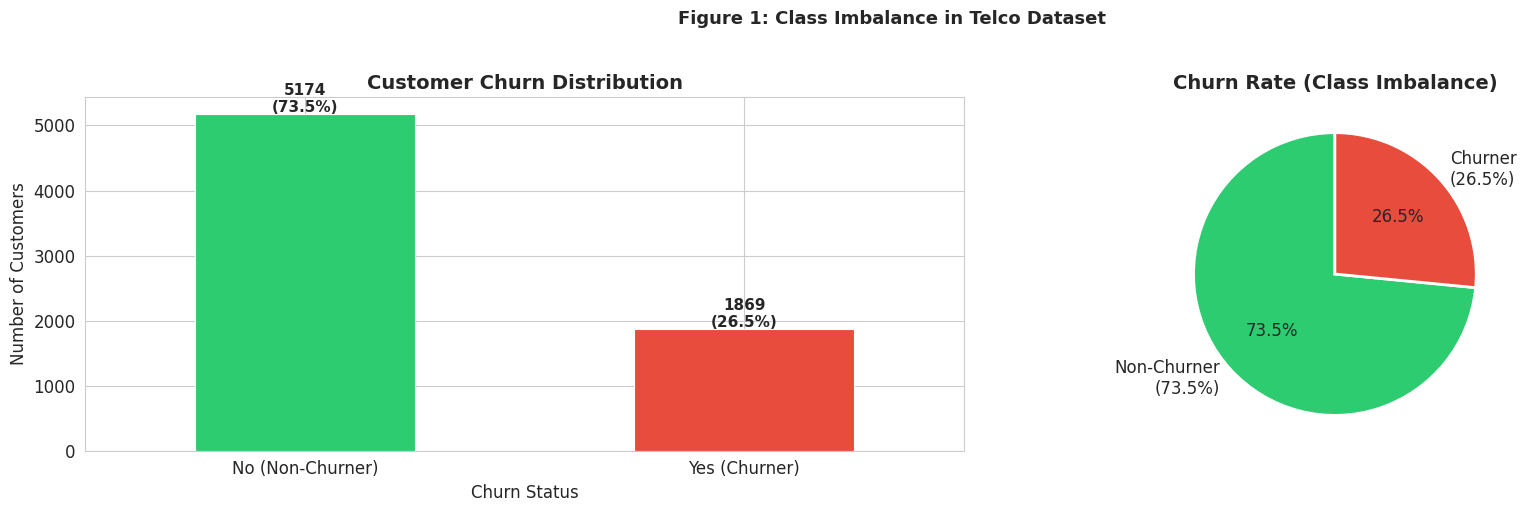

✅ Saved: fig1_class_imbalance.png


In [ ]:
# ============================================================
# CELL 8 — EDA: Class imbalance bar chart (Figure 1 in paper)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Left: count plot
churn_colors = ['#2ecc71', '#e74c3c']
df_raw['Churn'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=churn_colors, edgecolor='white', linewidth=0.8
)
axes[0].set_title('Customer Churn Distribution', fontweight='bold')
axes[0].set_xlabel('Churn Status')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticklabels(['No (Non-Churner)', 'Yes (Churner)'], rotation=0)
for i, v in enumerate(df_raw['Churn'].value_counts()):
    axes[0].text(i, v + 30, f'{v}\n({v/len(df_raw)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

# Right: pie chart
churn_pct_vals = df_raw['Churn'].value_counts()
axes[1].pie(churn_pct_vals,
            labels=['Non-Churner\n(73.5%)', 'Churner\n(26.5%)'],
            colors=churn_colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Rate (Class Imbalance)', fontweight='bold')

plt.suptitle('Figure 1: Class Imbalance in Telco Dataset', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig1_class_imbalance.png")

In [ ]:
# ============================================================
# CELL 9 — EDA: Missing values check
# ============================================================

# TotalCharges has hidden missing values (stored as empty strings)
# This is a known issue with this specific dataset — important to catch
df_check = df_raw.copy()
df_check['TotalCharges'] = pd.to_numeric(df_check['TotalCharges'], errors='coerce')

missing = df_check.isnull().sum()
missing_pct = (missing / len(df_check)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
}).query('`Missing Count` > 0')

if len(missing_df) > 0:
    print("── Columns with missing values ──")
    print(missing_df.to_string(index=False))
else:
    print("No missing values found after type conversion.")

print(f"\n✅ TotalCharges has {df_check['TotalCharges'].isna().sum()} missing values")
print("   These are customers with 0 tenure (new customers). Will fill with median.")

── Columns with missing values ──
      Column  Missing Count  Missing %
TotalCharges             11   0.156183

✅ TotalCharges has 11 missing values
   These are customers with 0 tenure (new customers). Will fill with median.


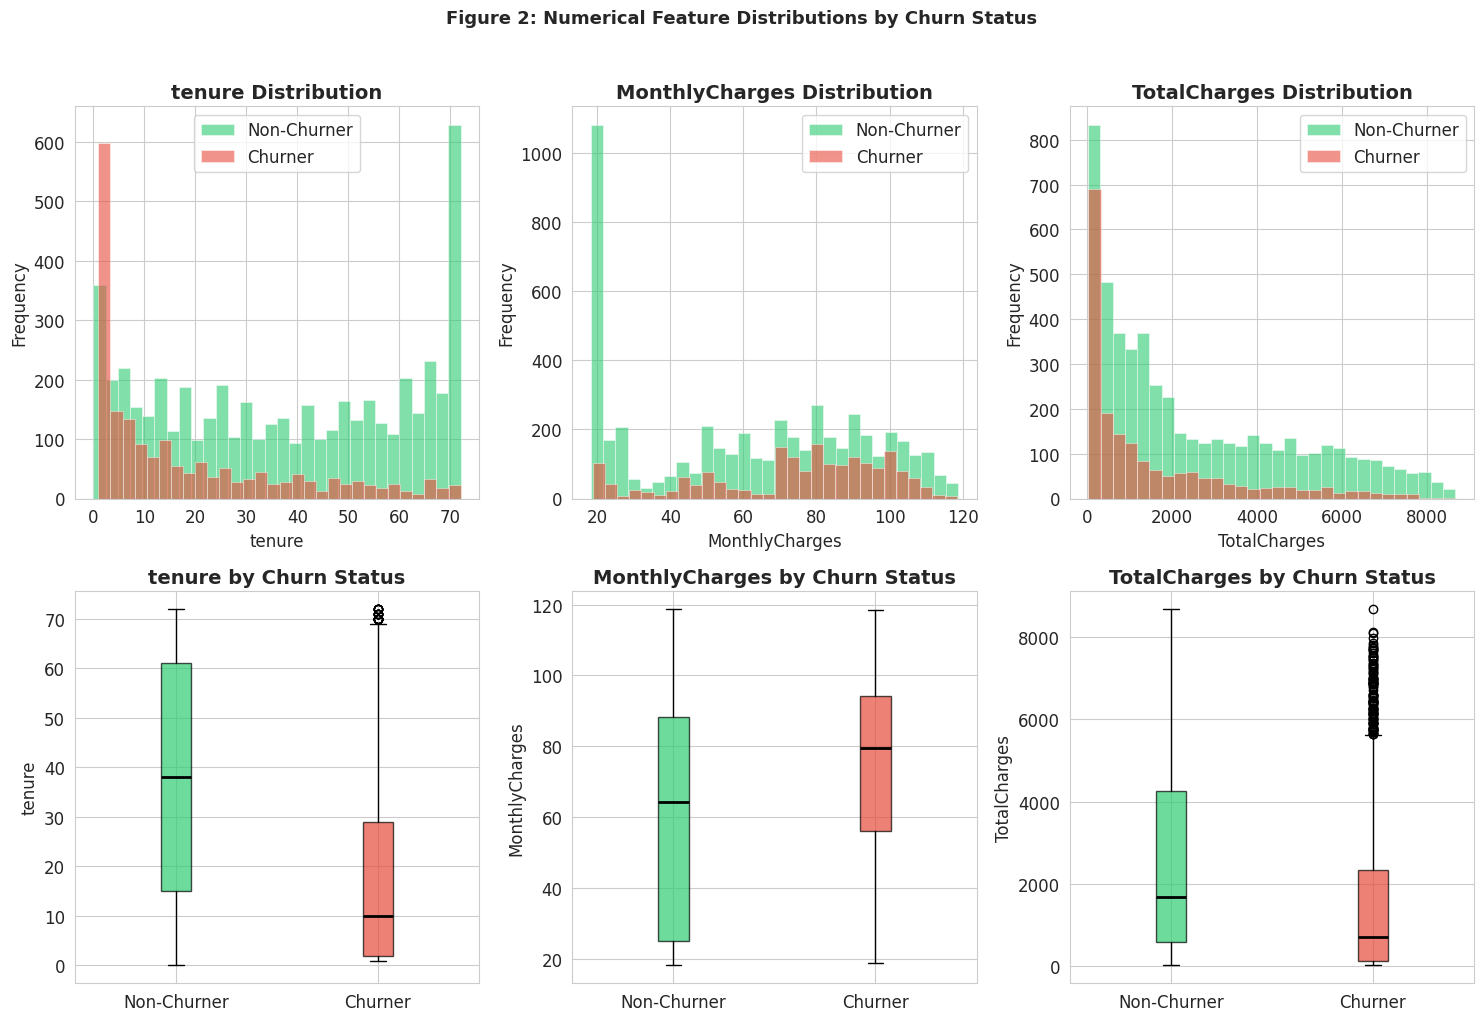

✅ Saved: fig2_numerical_distributions.png


In [ ]:
# ============================================================
# CELL 10 — EDA: Distribution of key numerical features
#            Split by churn status (Figure 2 in paper)
# ============================================================

df_eda = df_raw.copy()
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')

num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, feature in enumerate(num_features):
    # Top row: histogram by churn
    ax_hist = axes[0, idx]
    for churn_val, color, label in [('No', '#2ecc71', 'Non-Churner'),
                                     ('Yes', '#e74c3c', 'Churner')]:
        subset = df_eda[df_eda['Churn'] == churn_val][feature].dropna()
        ax_hist.hist(subset, bins=30, alpha=0.6, color=color,
                     label=label, edgecolor='white', linewidth=0.5)
    ax_hist.set_title(f'{feature} Distribution', fontweight='bold')
    ax_hist.set_xlabel(feature)
    ax_hist.set_ylabel('Frequency')
    ax_hist.legend()

    # Bottom row: box plot by churn
    ax_box = axes[1, idx]
    churn_no  = df_eda[df_eda['Churn'] == 'No'][feature].dropna()
    churn_yes = df_eda[df_eda['Churn'] == 'Yes'][feature].dropna()
    bp = ax_box.boxplot([churn_no, churn_yes],
                         labels=['Non-Churner', 'Churner'],
                         patch_artist=True,
                         medianprops={'color': 'black', 'linewidth': 2})
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    for patch in bp['boxes']:
        patch.set_alpha(0.7)
    ax_box.set_title(f'{feature} by Churn Status', fontweight='bold')
    ax_box.set_ylabel(feature)

plt.suptitle('Figure 2: Numerical Feature Distributions by Churn Status',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig2_numerical_distributions.png")

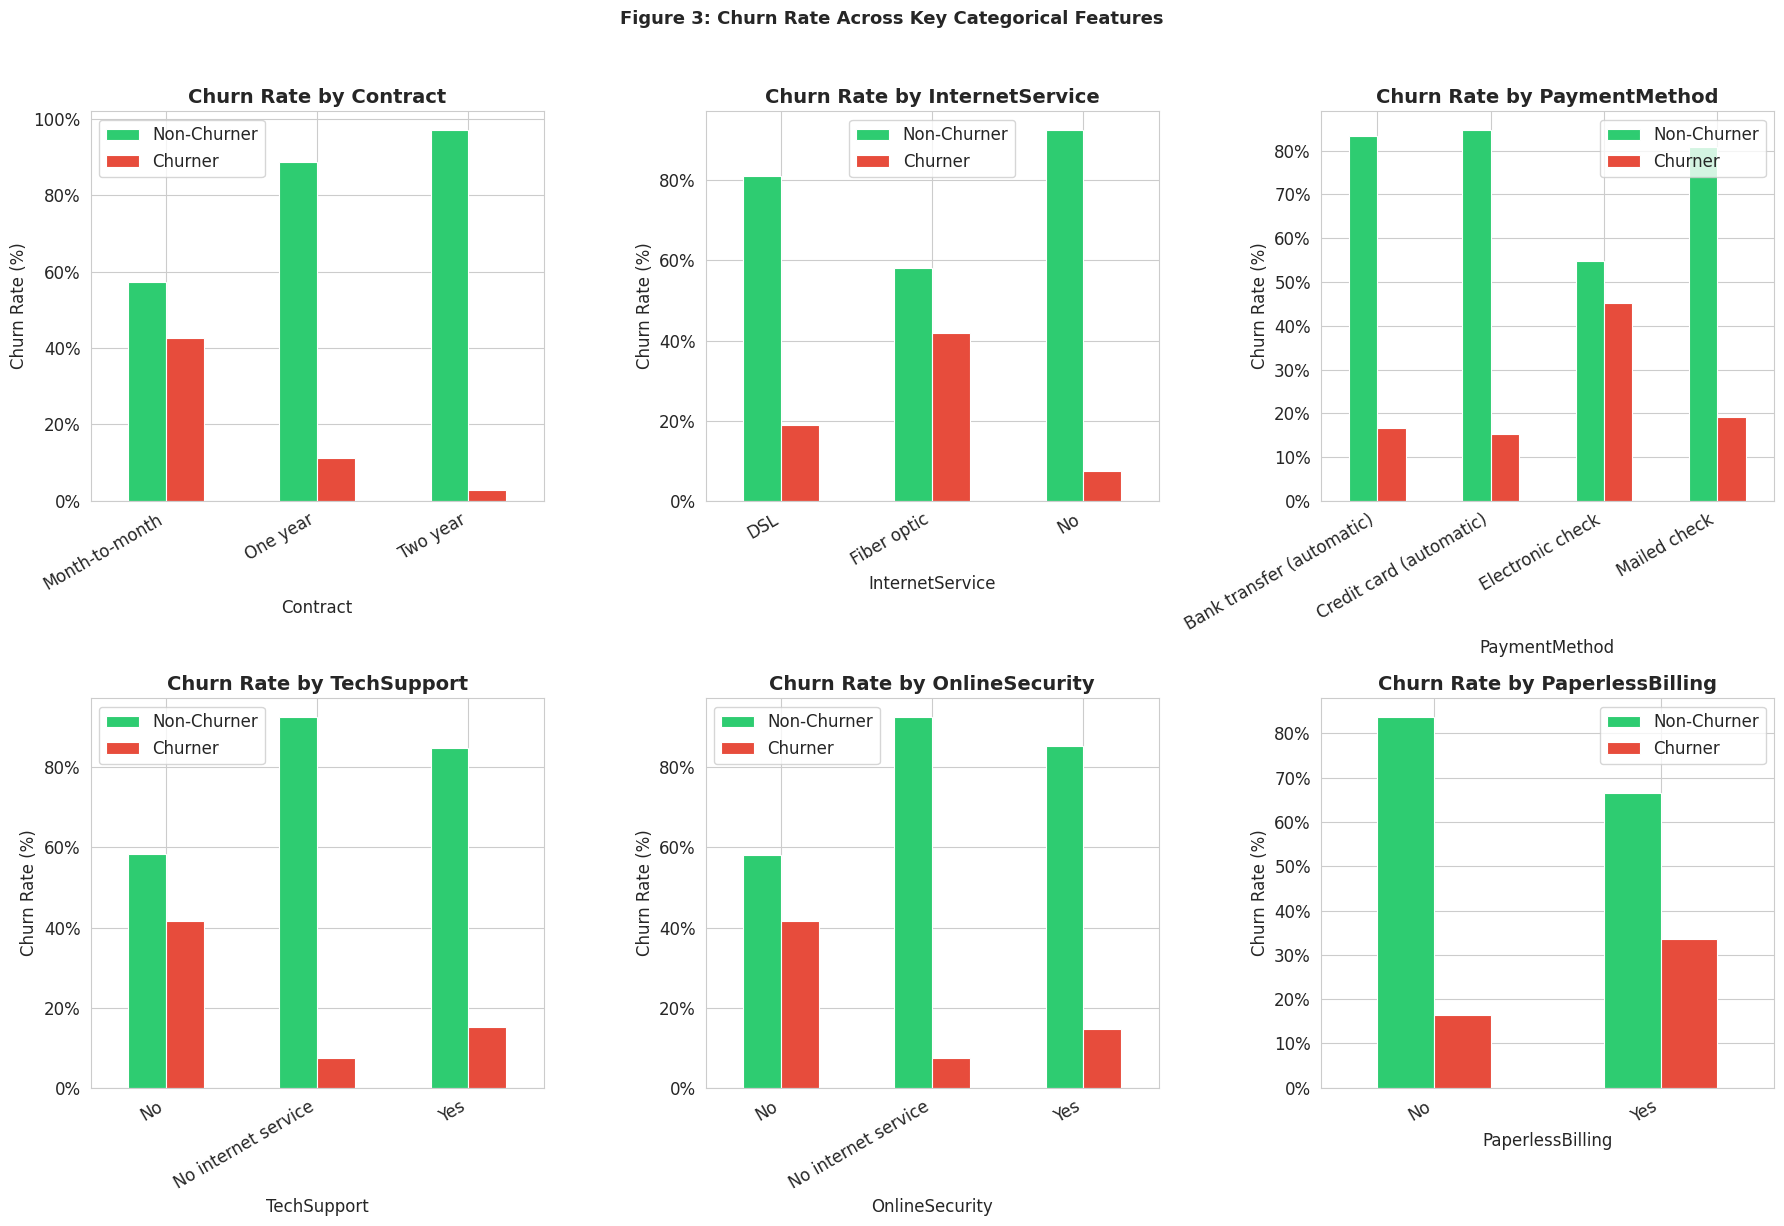

   Contract: Month-to-month ~42% | One-year ~11% | Two-year ~3%
   Fiber optic customers churn at ~42% vs DSL at ~19%.
   Electronic check payment method has highest churn at ~45%.
   No TechSupport → ~42% churn | With TechSupport → ~15% churn.
   No OnlineSecurity → ~42% churn | With OnlineSecurity → ~15% churn.
   Paperless billing customers churn more (~34%) vs non-paperless (~17%).


In [ ]:
# ============================================================
# CELL 11 — EDA: Categorical features vs Churn (Figure 3 in paper)
#            These are the most insightful plots for your paper
# ============================================================

cat_features = ['Contract', 'InternetService', 'PaymentMethod',
                'TechSupport', 'OnlineSecurity', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, feature in enumerate(cat_features):
    ct = pd.crosstab(df_raw[feature], df_raw['Churn'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[idx], color=['#2ecc71', '#e74c3c'],
            edgecolor='white', linewidth=0.8)
    axes[idx].set_title(f'Churn Rate by {feature}', fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Churn Rate (%)')
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=30, ha='right')
    axes[idx].legend(['Non-Churner', 'Churner'])
    axes[idx].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Figure 3: Churn Rate Across Key Categorical Features',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_categorical_churn_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print("   Contract: Month-to-month ~42% | One-year ~11% | Two-year ~3%")
print("   Fiber optic customers churn at ~42% vs DSL at ~19%.")
print("   Electronic check payment method has highest churn at ~45%.")
print("   No TechSupport → ~42% churn | With TechSupport → ~15% churn.")
print("   No OnlineSecurity → ~42% churn | With OnlineSecurity → ~15% churn.")
print("   Paperless billing customers churn more (~34%) vs non-paperless (~17%).")

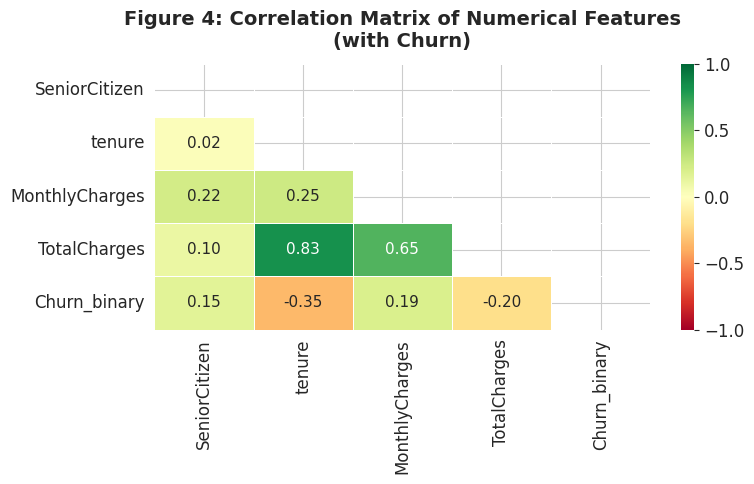

✅ Saved: fig4_correlation_heatmap.png

── Key correlations with Churn ──
MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.199484
tenure           -0.352229


In [ ]:
# ============================================================
# CELL 12 — EDA: Correlation heatmap (Figure 4 in paper)
# ============================================================

df_corr = df_raw.copy()
df_corr['TotalCharges']  = pd.to_numeric(df_corr['TotalCharges'], errors='coerce')
df_corr['Churn_binary']  = (df_corr['Churn'] == 'Yes').astype(int)
df_corr['SeniorCitizen'] = df_corr['SeniorCitizen'].astype(int)

# Only keep numeric columns for correlation
num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges',
            'TotalCharges', 'Churn_binary']
corr_matrix = df_corr[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # show lower triangle only
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax,
            annot_kws={'size': 11})
ax.set_title('Figure 4: Correlation Matrix of Numerical Features\n(with Churn)',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig4_correlation_heatmap.png")
print("\n── Key correlations with Churn ──")
churn_corr = corr_matrix['Churn_binary'].drop('Churn_binary').sort_values(ascending=False)
print(churn_corr.to_string())

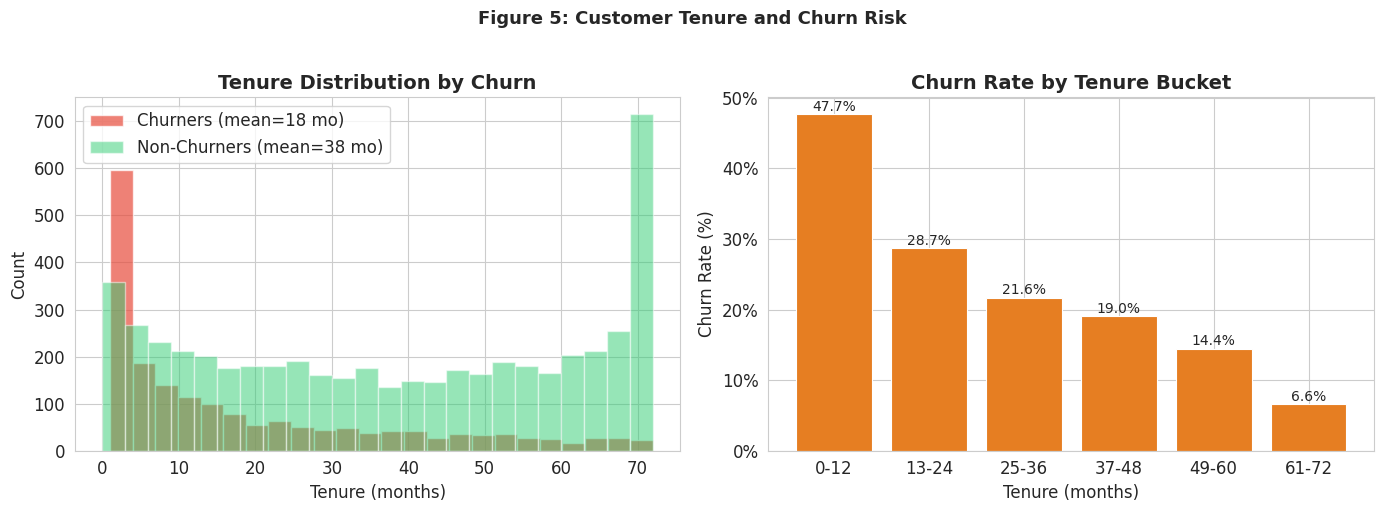

   0-12 mo: 47.7% | 13-24 mo: 28.7% | 25-36 mo: 21.6%
   37-48 mo: 19.0% | 49-60 mo: 14.4% | 61-72 mo: 6.6%
   Sharpest drop: 0-12 → 13-24 months (19 percentage points).
   Churner mean tenure = 18 mo vs Non-Churner mean tenure = 38 mo.
   Key paper insight: First 12 months is the highest churn risk window.
   Retention efforts should be strongest for new customers under 1 year.


In [ ]:
# ============================================================
# CELL 13 — EDA: Tenure analysis (very insightful for paper)
#            Shows customer lifecycle and churn risk by tenure
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: tenure distribution by churn
tenure_churners     = df_raw[df_raw['Churn'] == 'Yes']['tenure']
tenure_non_churners = df_raw[df_raw['Churn'] == 'No']['tenure']
axes[0].hist(tenure_churners, bins=24, alpha=0.7,
             color='#e74c3c', label=f'Churners (mean={tenure_churners.mean():.0f} mo)')
axes[0].hist(tenure_non_churners, bins=24, alpha=0.5,
             color='#2ecc71', label=f'Non-Churners (mean={tenure_non_churners.mean():.0f} mo)')
axes[0].set_title('Tenure Distribution by Churn', fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Right: churn rate by tenure bucket
df_raw['tenure_bucket'] = pd.cut(df_raw['tenure'],
                                  bins=[0, 12, 24, 36, 48, 60, 72],
                                  labels=['0-12', '13-24', '25-36', '37-48', '49-60', '61-72'])
churn_by_tenure = df_raw.groupby('tenure_bucket')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100).reset_index()
churn_by_tenure.columns = ['Tenure Bucket', 'Churn Rate %']
axes[1].bar(churn_by_tenure['Tenure Bucket'],
            churn_by_tenure['Churn Rate %'],
            color='#e67e22', edgecolor='white', linewidth=0.8)
axes[1].set_title('Churn Rate by Tenure Bucket', fontweight='bold')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, row in churn_by_tenure.iterrows():
    axes[1].text(i, row['Churn Rate %'] + 0.5,
                 f"{row['Churn Rate %']:.1f}%", ha='center', fontsize=10)

plt.suptitle('Figure 5: Customer Tenure and Churn Risk',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_tenure_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("   0-12 mo: 47.7% | 13-24 mo: 28.7% | 25-36 mo: 21.6%")
print("   37-48 mo: 19.0% | 49-60 mo: 14.4% | 61-72 mo: 6.6%")
print("   Sharpest drop: 0-12 → 13-24 months (19 percentage points).")
print("   Churner mean tenure = 18 mo vs Non-Churner mean tenure = 38 mo.")
print("   Key paper insight: First 12 months is the highest churn risk window.")
print("   Retention efforts should be strongest for new customers under 1 year.")

In [ ]:
# ============================================================
# CELL 14 — Full preprocessing pipeline (Step by Step)
# ============================================================

print("Starting preprocessing pipeline...")
print("=" * 50)

# ── Step 1: Work on a copy. Never modify raw data. ──────
df = df_raw.copy()
print("✅ Step 1: Working copy created. df_raw is preserved.")

# ── Step 2: Drop CustomerID (not a predictor) ──────────
df.drop(columns=['customerID'], inplace=True)
print("✅ Step 2: CustomerID dropped.")

# ── Step 3: Fix TotalCharges ───────────────────────────
# TotalCharges is stored as string. Empty strings = 11 new customers with 0 tenure.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
median_tc = df['TotalCharges'].median()
df['TotalCharges'].fillna(median_tc, inplace=True)
print(f"✅ Step 3: TotalCharges converted to float. "
      f"11 missing values filled with median (${median_tc:.2f}).")

# ── Step 4: Encode target variable (Churn: Yes/No → 1/0) ──
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
print(f"✅ Step 4: Target encoded. Churner=1, Non-Churner=0")
print(f"          Churners: {df['Churn'].sum()} | Non-Churners: {(df['Churn']==0).sum()}")

# ── Step 5: Identify column types ──────────────────────
binary_cols = []      # 2 unique values → Label Encoding (0/1)
multiclass_cols = []  # 3+ unique values → One-Hot Encoding
numeric_cols = []     # already numeric, just need scaling

for col in df.drop(columns=['Churn']).columns:
    if df[col].dtype == 'object':
        n_unique = df[col].nunique()
        if n_unique == 2:
            binary_cols.append(col)
        else:
            multiclass_cols.append(col)
    else:
        numeric_cols.append(col)

print(f"\n── Column Types Identified ──")
print(f"  Binary categorical  (Label Encode) : {binary_cols}")
print(f"  Multi  categorical  (One-Hot)      : {multiclass_cols}")
print(f"  Numeric             (Scale)        : {numeric_cols}")

Starting preprocessing pipeline...
✅ Step 1: Working copy created. df_raw is preserved.
✅ Step 2: CustomerID dropped.
✅ Step 3: TotalCharges converted to float. 11 missing values filled with median ($1397.47).
✅ Step 4: Target encoded. Churner=1, Non-Churner=0
          Churners: 1869 | Non-Churners: 5174

── Column Types Identified ──
  Binary categorical  (Label Encode) : ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
  Multi  categorical  (One-Hot)      : ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
  Numeric             (Scale)        : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'tenure_bucket']


In [ ]:
# ============================================================
# CELL 15 — Apply encodings
# ============================================================

# ── Step 6: Label encode binary columns ────────────────
le = LabelEncoder()
for col in binary_cols:
    original_vals = df[col].unique().tolist()
    df[col] = le.fit_transform(df[col])
    print(f"  Label encoded: {col:20s} | {original_vals} → {df[col].unique().tolist()}")

print(f"\n✅ Step 6: Label encoding done for {len(binary_cols)} binary columns.")

# ── Step 7: One-Hot encode multi-class columns ──────────
df = pd.get_dummies(df, columns=multiclass_cols, drop_first=False)
# Convert any True/False boolean columns created by get_dummies to 0/1
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

new_ohe_cols = [c for c in df.columns
                if any(c.startswith(mc + '_') for mc in multiclass_cols)]
print(f"\n✅ Step 7: One-Hot encoding done.")
print(f"   New columns created: {new_ohe_cols}")
print(f"   Dataset shape after encoding: {df.shape}")

# ── Step 8: Final check ─────────────────────────────────
print(f"\n── Final dtype check ──")
remaining_objects = df.select_dtypes(include='object').columns.tolist()
if remaining_objects:
    print(f"  ⚠️  Object columns still present: {remaining_objects}")
else:
    print(f"  ✅ All columns are now numeric. Ready for modeling.")

  Label encoded: gender               | ['Female', 'Male'] → [0, 1]
  Label encoded: Partner              | ['Yes', 'No'] → [1, 0]
  Label encoded: Dependents           | ['No', 'Yes'] → [0, 1]
  Label encoded: PhoneService         | ['No', 'Yes'] → [0, 1]
  Label encoded: PaperlessBilling     | ['Yes', 'No'] → [1, 0]

✅ Step 6: Label encoding done for 5 binary columns.

✅ Step 7: One-Hot encoding done.
   New columns created: ['MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No', 'Streami

In [ ]:
# ============================================================
# CELL 16 — Feature / Target split + Scaling + Train-Test Split
# ============================================================

# Remove EDA helper columns — not model features
df.drop(columns=['tenure_bucket'], inplace=True, errors='ignore')

# Also clean numeric_cols list in case it captured tenure_bucket
numeric_cols = [c for c in numeric_cols if c in df.columns]

# ── Step 9: Separate features (X) and target (y) ────────
X = df.drop(columns=['Churn'])
y = df['Churn']
print(f"✅ Step 9: X shape = {X.shape} | y shape = {y.shape}")
print(f"          Features: {X.shape[1]} | Samples: {X.shape[0]}")

# ── Step 10: Scale numerical features ───────────────────
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])
print(f"\n✅ Step 10: StandardScaler applied to {len(numeric_cols)} numeric columns: {numeric_cols}")
print(f"           Mean before scaling (tenure): {X['tenure'].mean():.2f}")
print(f"           Mean after scaling  (tenure): {X_scaled['tenure'].mean():.4f}  ← should be ~0")
print(f"           Std  after scaling  (tenure): {X_scaled['tenure'].std():.4f}   ← should be ~1")

# ── Step 11: Stratified Train-Test Split ────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"\n✅ Step 11: Stratified train-test split complete.")
print(f"   Training set   : {X_train.shape[0]} samples | "
      f"Churn rate = {y_train.mean()*100:.1f}%")
print(f"   Test set       : {X_test.shape[0]} samples | "
      f"Churn rate = {y_test.mean()*100:.1f}%")
print(f"   ← Both rates should be ~26.5%. Stratification is working.")

✅ Step 9: X shape = (7043, 40) | y shape = (7043,)
          Features: 40 | Samples: 7043

✅ Step 10: StandardScaler applied to 4 numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
           Mean before scaling (tenure): 32.37
           Mean after scaling  (tenure): -0.0000  ← should be ~0
           Std  after scaling  (tenure): 1.0001   ← should be ~1

✅ Step 11: Stratified train-test split complete.
   Training set   : 5634 samples | Churn rate = 26.5%
   Test set       : 1409 samples | Churn rate = 26.5%
   ← Both rates should be ~26.5%. Stratification is working.


In [ ]:
# ============================================================
# CELL 17 — Save preprocessing info to results dict
# ============================================================

results['dataset_info'].update({
    "features_after_encoding"  : int(X_scaled.shape[1]),
    "train_samples"            : int(X_train.shape[0]),
    "test_samples"             : int(X_test.shape[0]),
    "train_churn_rate_pct"     : round(float(y_train.mean() * 100), 2),
    "test_churn_rate_pct"      : round(float(y_test.mean() * 100), 2),
    "binary_encoded_cols"      : binary_cols,
    "ohe_cols"                 : multiclass_cols,
    "scaled_cols"              : numeric_cols,
    "random_state"             : 42
})

print("✅ Preprocessing info saved to results['dataset_info']")
print(json.dumps(results['dataset_info'], indent=2))

✅ Preprocessing info saved to results['dataset_info']
{
  "name": "IBM Telco Customer Churn",
  "source": "Kaggle: blastchar/telco-customer-churn",
  "total_records": 7043,
  "total_features": 21,
  "churn_count": 1869,
  "non_churn_count": 5174,
  "churn_rate_pct": 26.54,
  "imbalance_ratio": 2.77,
  "features_after_encoding": 40,
  "train_samples": 5634,
  "test_samples": 1409,
  "train_churn_rate_pct": 26.54,
  "test_churn_rate_pct": 26.54,
  "binary_encoded_cols": [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
  ],
  "ohe_cols": [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod"
  ],
  "scaled_cols": [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
  ],
  "random_state": 42
}


In [ ]:
# ============================================================
# CELL 18 — Verify everything is ready for Week 2
# ============================================================

print("=" * 55)
print("  WEEK 1 COMPLETION CHECKLIST")
print("=" * 55)

checks = {
    "Raw data loaded (df_raw)"           : 'df_raw' in dir() and len(df_raw) > 0,
    "Clean data ready (df)"              : 'df' in dir() and df.select_dtypes('object').empty,
    "X_train ready"                      : 'X_train' in dir(),
    "X_test ready"                       : 'X_test' in dir(),
    "y_train ready"                      : 'y_train' in dir(),
    "y_test ready"                       : 'y_test' in dir(),
    "Results dict initialized"           : bool(results['dataset_info']),
    "save_metrics() function ready"      : callable(save_metrics),
    "show_results_table() function ready": callable(show_results_table),
    "EDA plots saved"                    : os.path.exists('fig1_class_imbalance.png'),
}

all_good = True
for check, status in checks.items():
    icon = "✅" if status else "❌"
    print(f"  {icon}  {check}")
    if not status:
        all_good = False

print("=" * 55)
if all_good:
    print("  🎉 Week 1 COMPLETE. Ready to start Week 2 modeling.")
else:
    print("  ⚠️  Some checks failed. Review the cells above.")
print("=" * 55)
print(f"\n  Training features shape : {X_train.shape}")
print(f"  Test features shape     : {X_test.shape}")
print(f"  Feature list ({X_train.shape[1]} total) : {X_train.columns.tolist()}")

  WEEK 1 COMPLETION CHECKLIST
  ✅  Raw data loaded (df_raw)
  ✅  Clean data ready (df)
  ✅  X_train ready
  ✅  X_test ready
  ✅  y_train ready
  ✅  y_test ready
  ✅  Results dict initialized
  ✅  save_metrics() function ready
  ✅  show_results_table() function ready
  ✅  EDA plots saved
  🎉 Week 1 COMPLETE. Ready to start Week 2 modeling.

  Training features shape : (5634, 40)
  Test features shape     : (1409, 40)
  Feature list (40 total) : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No', 'TechSu

In [ ]:
# ============================================================
# CELL 19 — Define all 5 baseline models
# Default hyperparameters — no tuning, no resampling
# random_state=42 everywhere for reproducibility
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000        # increase from default 100 to ensure convergence
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42      # default settings — will likely overfit, that's expected
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,    # default in sklearn
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        verbosity=0          # suppress XGBoost training logs
    ),
    "LightGBM": LGBMClassifier(
        random_state=42,
        verbose=-1           # suppress LightGBM training logs
    )
}

print("✅ 5 models defined with default hyperparameters.")
print("   Models:", list(models.keys()))

✅ 5 models defined with default hyperparameters.
   Models: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM']


In [ ]:
# ============================================================
# CELL 20 — Train all 5 baseline models
# Save every result immediately into results['baseline']
# ============================================================

print("=" * 60)
print("  TRAINING BASELINE MODELS — NO RESAMPLING")
print("=" * 60)

for model_name, model in models.items():
    print(f"\n── {model_name} ──")

    # Train
    model.fit(X_train, y_train)

    # Predict class labels and probabilities
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # probability of churn (class 1)

    # Save all 6 metrics into results dict immediately
    save_metrics(
        section   = 'baseline',
        key       = model_name,
        y_true    = y_test,
        y_pred    = y_pred,
        y_prob    = y_prob
    )

print("\n" + "=" * 60)
print("  ALL 5 BASELINE MODELS TRAINED AND SAVED")
print("=" * 60)

  TRAINING BASELINE MODELS — NO RESAMPLING

── Logistic Regression ──
  ✅ Saved → results['baseline']['Logistic Regression']
     Acc=0.8041 | P=0.6541 | R=0.5561 | F1=0.6012 | AUC=0.8419 | MCC=0.4752

── Decision Tree ──
  ✅ Saved → results['baseline']['Decision Tree']
     Acc=0.7168 | P=0.468 | R=0.4893 | F1=0.4784 | AUC=0.6439 | MCC=0.2843

── Random Forest ──
  ✅ Saved → results['baseline']['Random Forest']
     Acc=0.7828 | P=0.6104 | R=0.5027 | F1=0.5513 | AUC=0.818 | MCC=0.4132

── XGBoost ──
  ✅ Saved → results['baseline']['XGBoost']
     Acc=0.785 | P=0.606 | R=0.5428 | F1=0.5726 | AUC=0.8254 | MCC=0.4307

── LightGBM ──
  ✅ Saved → results['baseline']['LightGBM']
     Acc=0.7906 | P=0.6254 | R=0.5267 | F1=0.5718 | AUC=0.8309 | MCC=0.4374

  ALL 5 BASELINE MODELS TRAINED AND SAVED


In [ ]:
# ============================================================
# CELL 21 — Display baseline results as a clean table
# This becomes Table 1 in your paper
# ============================================================

baseline_df = show_results_table('baseline', 'Table 1: Baseline Results (No Resampling)')

# Highlight the best value in each column
print("\n── Best value per metric ──")
for col in ['Accuracy','Precision','Recall','F1','AUC','MCC']:
    best_model = baseline_df[col].idxmax()
    best_val   = baseline_df[col].max()
    print(f"  Best {col:12s}: {best_model:25s} ({best_val:.4f})")

print("\n── Focus on Recall — most important for churn ──")
print("   Recall tells you: of all actual churners, how many did the model catch?")
print("   Low recall = model is MISSING real churners = business loss.")
print("   This motivates the entire imbalance handling work in Week 3-4.")


  Table 1: Baseline Results (No Resampling)
                     Accuracy  Precision  Recall      F1     AUC     MCC
Logistic Regression    0.8041     0.6541  0.5561  0.6012  0.8419  0.4752
Decision Tree          0.7168     0.4680  0.4893  0.4784  0.6439  0.2843
Random Forest          0.7828     0.6104  0.5027  0.5513  0.8180  0.4132
XGBoost                0.7850     0.6060  0.5428  0.5726  0.8254  0.4307
LightGBM               0.7906     0.6254  0.5267  0.5718  0.8309  0.4374


── Best value per metric ──
  Best Accuracy    : Logistic Regression       (0.8041)
  Best Precision   : Logistic Regression       (0.6541)
  Best Recall      : Logistic Regression       (0.5561)
  Best F1          : Logistic Regression       (0.6012)
  Best AUC         : Logistic Regression       (0.8419)
  Best MCC         : Logistic Regression       (0.4752)

── Focus on Recall — most important for churn ──
   Recall tells you: of all actual churners, how many did the model catch?
   Low recall = model is M

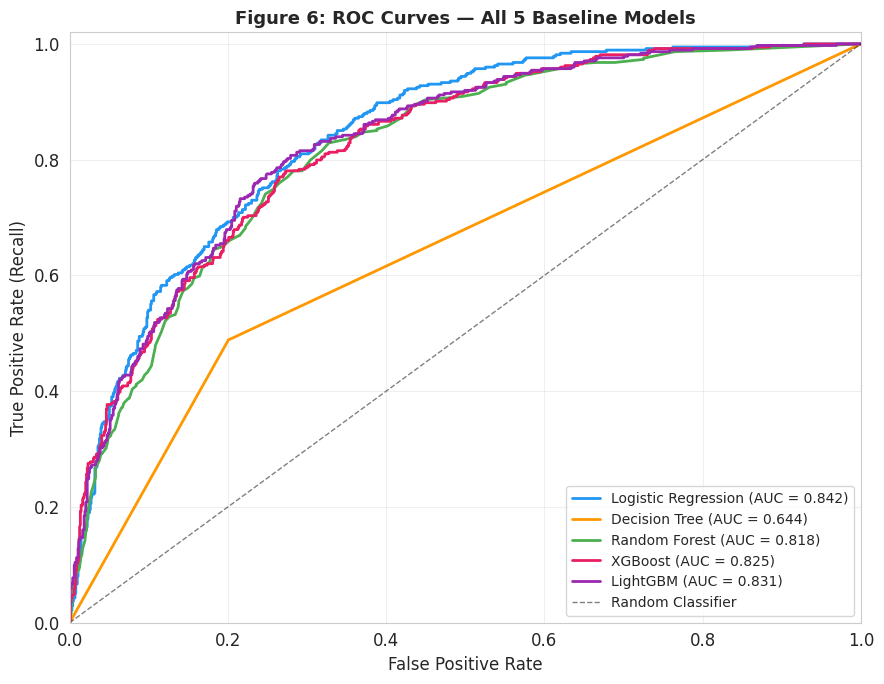

✅ Saved: fig6_roc_curves_baseline.png


In [ ]:
# ============================================================
# CELL 22 — ROC Curves for all 5 models (Figure 6 in paper)
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

colors = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63', '#9C27B0']

for (model_name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{model_name} (AUC = {auc_val:.3f})')

# Diagonal reference line (random classifier)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('Figure 6: ROC Curves — All 5 Baseline Models', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('fig6_roc_curves_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig6_roc_curves_baseline.png")

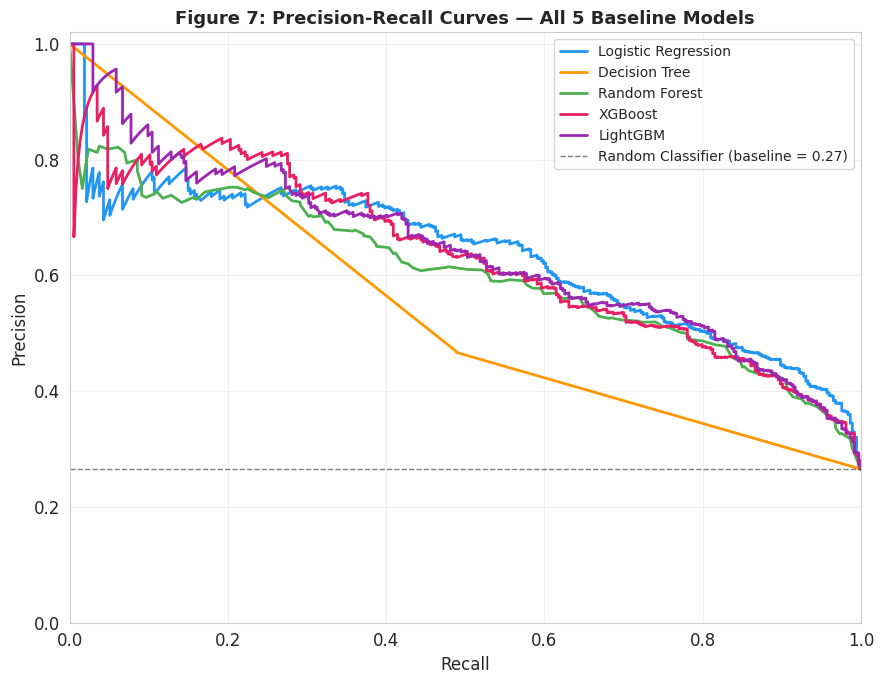

✅ Saved: fig7_pr_curves_baseline.png

── Why PR curves matter for your paper ──
   With 26.5% churn rate, a random model has precision = 0.265.
   Any model above that dashed line is better than random.
   AUC-PR is a stricter and more honest evaluation for imbalanced data.


In [ ]:
# ============================================================
# CELL 23 — Precision-Recall Curves (Figure 7 in paper)
# PR curves are MORE informative than ROC for imbalanced data
# Always include both in your paper
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

for (model_name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ax.plot(recall, precision, color=color, linewidth=2, label=model_name)

# Baseline: random classifier on imbalanced data = churn rate
baseline_pr = y_test.mean()
ax.axhline(y=baseline_pr, color='black', linestyle='--',
           linewidth=1, alpha=0.5,
           label=f'Random Classifier (baseline = {baseline_pr:.2f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Figure 7: Precision-Recall Curves — All 5 Baseline Models',
             fontweight='bold', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('fig7_pr_curves_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig7_pr_curves_baseline.png")
print("\n── Why PR curves matter for your paper ──")
print("   With 26.5% churn rate, a random model has precision = 0.265.")
print("   Any model above that dashed line is better than random.")
print("   AUC-PR is a stricter and more honest evaluation for imbalanced data.")

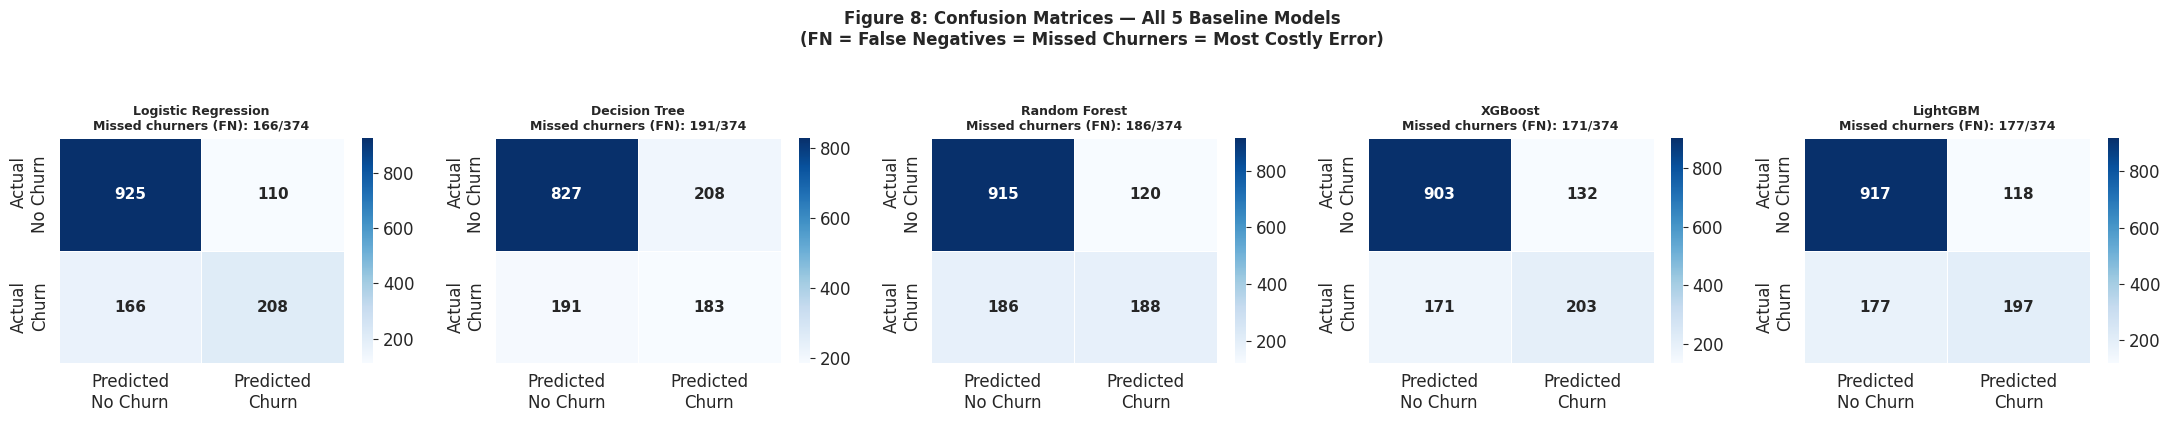

✅ Saved: fig8_confusion_matrices_baseline.png


In [ ]:
# ============================================================
# CELL 24 — Confusion matrices for all 5 models (Figure 8)
# Shows exactly how many churners each model misses (FN)
# FN = False Negatives = missed churners = business loss
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for idx, (model_name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx],
                cmap='Blues', linewidths=0.5,
                xticklabels=['Predicted\nNo Churn', 'Predicted\nChurn'],
                yticklabels=['Actual\nNo Churn', 'Actual\nChurn'],
                annot_kws={'size': 11, 'weight': 'bold'})

    # Calculate and show missed churners
    fn = cm[1][0]   # False Negatives = actual churners predicted as non-churners
    fp = cm[0][1]   # False Positives = non-churners predicted as churners
    total_actual_churners = cm[1][0] + cm[1][1]

    axes[idx].set_title(
        f'{model_name}\nMissed churners (FN): {fn}/{total_actual_churners}',
        fontsize=9, fontweight='bold'
    )

plt.suptitle('Figure 8: Confusion Matrices — All 5 Baseline Models\n'
             '(FN = False Negatives = Missed Churners = Most Costly Error)',
             fontsize=12, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('fig8_confusion_matrices_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig8_confusion_matrices_baseline.png")

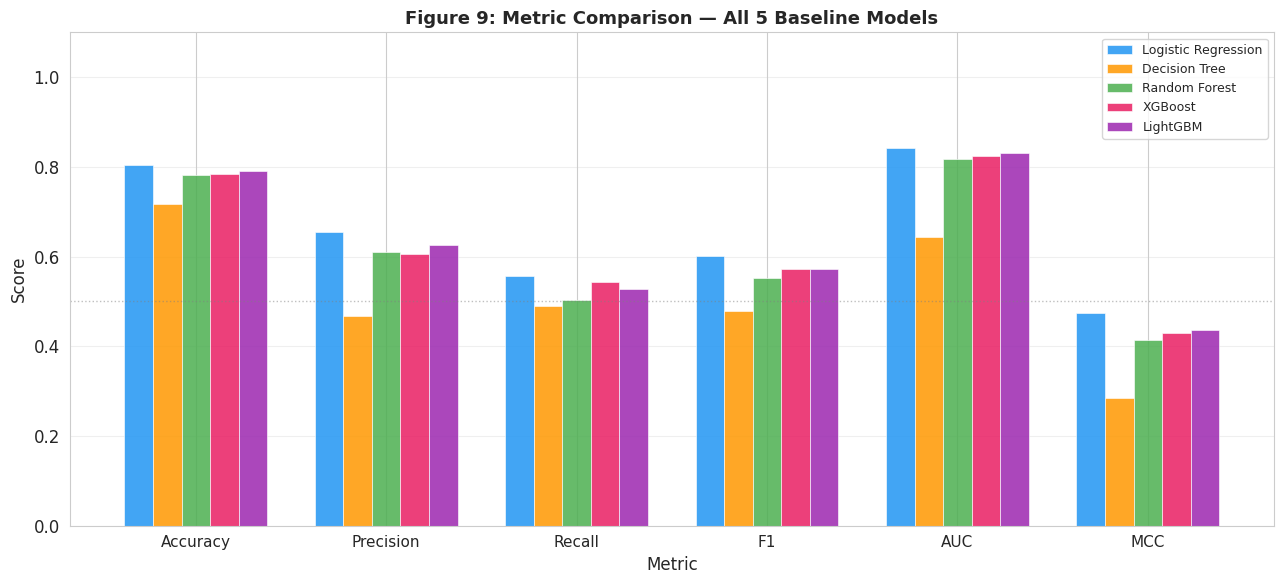

✅ Saved: fig9_metric_comparison_baseline.png


In [ ]:
# ============================================================
# CELL 25 — Side-by-side metric comparison bar chart
# Visual summary of all 5 models across all 6 metrics
# Strong visual for your paper's results section
# ============================================================

baseline_df = pd.DataFrame(results['baseline']).T
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC', 'MCC']
baseline_plot = baseline_df[
    ['accuracy','precision','recall','f1','auc','mcc']
].copy()
baseline_plot.columns = metrics_to_plot

fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(metrics_to_plot))
width = 0.15
offsets = [-2, -1, 0, 1, 2]

for i, (model_name, color) in enumerate(zip(models.keys(), colors)):
    vals = baseline_plot.loc[model_name].values.astype(float)
    bars = ax.bar(x + offsets[i] * width, vals,
                  width, label=model_name, color=color,
                  alpha=0.85, edgecolor='white', linewidth=0.5)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Figure 9: Metric Comparison — All 5 Baseline Models',
             fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim([0, 1.1])
ax.legend(loc='upper right', fontsize=9)
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig9_metric_comparison_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig9_metric_comparison_baseline.png")

In [ ]:
# ============================================================
# CELL 26 — Week 2 summary: findings + paper writing notes
# ============================================================

print("=" * 60)
print("  WEEK 2 COMPLETE — BASELINE RESULTS SUMMARY")
print("=" * 60)

baseline_df = pd.DataFrame(results['baseline']).T

# Best model by each metric
print("\n── Best model per metric ──")
for metric in ['accuracy','precision','recall','f1','auc','mcc']:
    best = baseline_df[metric].astype(float).idxmax()
    val  = baseline_df[metric].astype(float).max()
    print(f"  {metric:12s}: {best:25s} = {val:.4f}")

# Recall specifically — the critical metric
print("\n── Recall breakdown (most important metric) ──")
recall_series = baseline_df['recall'].astype(float).sort_values(ascending=False)
for model, val in recall_series.items():
    missed = int((1 - val) * y_test.sum())
    print(f"  {model:25s}: Recall = {val:.4f} "
          f"| Missed churners ≈ {missed} out of {y_test.sum()}")

print("\n── Key insight for your paper ──")
print("   High accuracy does NOT mean good churn prediction.")
print("   A model predicting nobody churns gets ~73.5% accuracy but 0% recall.")
print("   This directly motivates your Contribution 1: imbalance handling.")
print("   Write this exact argument in your Introduction and Results sections.")

print("\n── Figures saved this week ──")
for f in ['fig6_roc_curves_baseline.png',
          'fig7_pr_curves_baseline.png',
          'fig8_confusion_matrices_baseline.png',
          'fig9_metric_comparison_baseline.png']:
    exists = "✅" if os.path.exists(f) else "❌"
    print(f"  {exists} {f}")

print("\n── What to show your professor (Week 2 checkpoint) ──")
print("  Show: baseline results table + confusion matrices.")
print("  Say : 'These are the results with no imbalance handling.'")
print("         'Notice how Recall for churners is low across all models.'")
print("         'This is the exact problem my Contribution 1 addresses.'")
print("  Wait for professor approval before moving to Week 3.")

  WEEK 2 COMPLETE — BASELINE RESULTS SUMMARY

── Best model per metric ──
  accuracy    : Logistic Regression       = 0.8041
  precision   : Logistic Regression       = 0.6541
  recall      : Logistic Regression       = 0.5561
  f1          : Logistic Regression       = 0.6012
  auc         : Logistic Regression       = 0.8419
  mcc         : Logistic Regression       = 0.4752

── Recall breakdown (most important metric) ──
  Logistic Regression      : Recall = 0.5561 | Missed churners ≈ 166 out of 374
  XGBoost                  : Recall = 0.5428 | Missed churners ≈ 170 out of 374
  LightGBM                 : Recall = 0.5267 | Missed churners ≈ 177 out of 374
  Random Forest            : Recall = 0.5027 | Missed churners ≈ 185 out of 374
  Decision Tree            : Recall = 0.4893 | Missed churners ≈ 191 out of 374

── Key insight for your paper ──
   High accuracy does NOT mean good churn prediction.
   A model predicting nobody churns gets ~73.5% accuracy but 0% recall.
   This dire

In [ ]:
# ============================================================
# CELL 27 — Define all 5 resampling strategies
# Understand what each one does before running
# ============================================================

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek, SMOTEENN

# Strategy 1: No resampling — already done in Week 2
# Carried forward from results['baseline']

# Strategy 2: SMOTE
# Creates synthetic minority samples by interpolating between
# existing churner records. Balances dataset to 50/50.
smote = SMOTE(random_state=42)

# Strategy 3: SMOTE-Tomek
# SMOTE first (adds synthetic churners) then Tomek Links cleaning
# (removes borderline ambiguous samples from both classes).
# Result: balanced + cleaner decision boundary.
smote_tomek = SMOTETomek(random_state=42)

# Strategy 4: SMOTEENN
# SMOTE first then ENN (Edited Nearest Neighbors) cleaning.
# ENN is more aggressive than Tomek — removes any sample
# misclassified by its 3 nearest neighbors from BOTH classes.
# Result: smaller but much cleaner dataset.
smote_enn = SMOTEENN(random_state=42)

# Strategy 5: Class weight
# No new data created. Just tells the model:
# "penalize mistakes on churners more heavily."
# Implemented directly in model parameters — see Cell 28.

resampling_strategies = {
    'smote'       : smote,
    'smote_tomek' : smote_tomek,
    'smoteenn'    : smote_enn,
}

print("✅ Resampling strategies defined.")
print("   SMOTE        : oversample minority class synthetically")
print("   SMOTE-Tomek  : SMOTE + remove borderline noise")
print("   SMOTEENN     : SMOTE + aggressive noise removal (both classes)")
print("   Class-weight : no resampling, model-level penalty adjustment")

✅ Resampling strategies defined.
   SMOTE        : oversample minority class synthetically
   SMOTE-Tomek  : SMOTE + remove borderline noise
   SMOTEENN     : SMOTE + aggressive noise removal (both classes)
   Class-weight : no resampling, model-level penalty adjustment


In [ ]:
# ============================================================
# CELL 28 — Define models WITH class_weight for strategy 5
# These are separate model instances from Cell 19
# ============================================================

models_weighted = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        class_weight='balanced',
        n_estimators=100,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        # XGBoost uses scale_pos_weight instead of class_weight
        # Formula: scale_pos_weight = count(non-churners) / count(churners)
        scale_pos_weight = int((y_train == 0).sum() / (y_train == 1).sum()),
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    "LightGBM": LGBMClassifier(
        class_weight='balanced',
        random_state=42,
        verbose=-1
    )
}

ratio = round((y_train == 0).sum() / (y_train == 1).sum(), 2)
print(f"✅ Class-weighted models defined.")
print(f"   scale_pos_weight for XGBoost = {ratio}")
print(f"   (= non-churners / churners in training set)")
print(f"   All other models use class_weight='balanced'")

✅ Class-weighted models defined.
   scale_pos_weight for XGBoost = 2.77
   (= non-churners / churners in training set)
   All other models use class_weight='balanced'


In [ ]:
# ============================================================
# CELL 29 — Run the full 5x5 experiment matrix
# 5 models x 5 strategies = 25 combinations
# Save every result immediately
# This is your entire Contribution 1
# ============================================================

print("=" * 65)
print("  CONTRIBUTION 1 — FULL IMBALANCE EXPERIMENT MATRIX")
print("  5 Models × 5 Strategies = 25 Experiments")
print("=" * 65)

# ── Copy baseline results into imbalance section ──────────
# No resampling results already exist in results['baseline']
# Copy them into results['imbalance']['no_resampling'] for consistency
for model_name in models.keys():
    results['imbalance']['no_resampling'][model_name] = \
        results['baseline'][model_name].copy()
print("\n✅ No-resampling results copied from baseline.")

# ── Run SMOTE, SMOTE-Tomek, SMOTEENN ──────────────────────
for strategy_name, resampler in resampling_strategies.items():
    print(f"\n{'─'*55}")
    print(f"  Strategy: {strategy_name.upper()}")
    print(f"{'─'*55}")

    # Apply resampling ONLY on training data — never on test
    X_res, y_res = resampler.fit_resample(X_train, y_train)

    print(f"  Training set size before: {len(X_train)} "
          f"(churners: {y_train.sum()})")
    print(f"  Training set size after : {len(X_res)} "
          f"(churners: {y_res.sum()})")

    for model_name, model in models.items():
        # Fresh model instance to avoid contamination between strategies
        fresh_model = model.__class__(**model.get_params())
        fresh_model.fit(X_res, y_res)

        y_pred = fresh_model.predict(X_test)
        y_prob = fresh_model.predict_proba(X_test)[:, 1]

        save_metrics(
            section   = 'imbalance',
            key       = f"{strategy_name}__{model_name}",
            y_true    = y_test,
            y_pred    = y_pred,
            y_prob    = y_prob,
            extra_info= {'strategy': strategy_name, 'model': model_name}
        )

# ── Run Class-weight strategy ──────────────────────────────
print(f"\n{'─'*55}")
print(f"  Strategy: CLASS_WEIGHT")
print(f"{'─'*55}")
print(f"  No resampling applied — model-level penalty only.")

for model_name, model in models_weighted.items():
    model.fit(X_train, y_train)  # original imbalanced training data

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    save_metrics(
        section   = 'imbalance',
        key       = f"class_weight__{model_name}",
        y_true    = y_test,
        y_pred    = y_pred,
        y_prob    = y_prob,
        extra_info= {'strategy': 'class_weight', 'model': model_name}
    )

print(f"\n{'='*65}")
print(f"  ALL 25 EXPERIMENTS COMPLETE AND SAVED")
print(f"{'='*65}")

  CONTRIBUTION 1 — FULL IMBALANCE EXPERIMENT MATRIX
  5 Models × 5 Strategies = 25 Experiments

✅ No-resampling results copied from baseline.

───────────────────────────────────────────────────────
  Strategy: SMOTE
───────────────────────────────────────────────────────
  Training set size before: 5634 (churners: 1495)
  Training set size after : 8278 (churners: 4139)
  ✅ Saved → results['imbalance']['smote__Logistic Regression']
     Acc=0.7686 | P=0.5519 | R=0.6818 | F1=0.61 | AUC=0.8378 | MCC=0.4532
  ✅ Saved → results['imbalance']['smote__Decision Tree']
     Acc=0.7154 | P=0.4685 | R=0.5374 | F1=0.5006 | AUC=0.6583 | MCC=0.3043
  ✅ Saved → results['imbalance']['smote__Random Forest']
     Acc=0.7679 | P=0.5592 | R=0.5936 | F1=0.5759 | AUC=0.8158 | MCC=0.4167
  ✅ Saved → results['imbalance']['smote__XGBoost']
     Acc=0.7615 | P=0.5455 | R=0.6096 | F1=0.5758 | AUC=0.8143 | MCC=0.4119
  ✅ Saved → results['imbalance']['smote__LightGBM']
     Acc=0.7743 | P=0.566 | R=0.6417 | F1=0.6

In [ ]:
# ============================================================
# CELL 30 — Build the master comparison table
# This is the most important table in your paper
# ============================================================

# Build a structured DataFrame from results
rows = []
strategy_order = ['no_resampling', 'smote', 'smote_tomek', 'smoteenn', 'class_weight']
strategy_labels = {
    'no_resampling' : 'No Resampling',
    'smote'         : 'SMOTE',
    'smote_tomek'   : 'SMOTE-Tomek',
    'smoteenn'      : 'SMOTEENN',
    'class_weight'  : 'Class Weight'
}

for strategy in strategy_order:
    for model_name in models.keys():
        if strategy == 'no_resampling':
            key = model_name
            data = results['imbalance']['no_resampling'].get(key, {})
        else:
            key = f"{strategy}__{model_name}"
            data = results['imbalance'].get(key, {})

        if data:
            rows.append({
                'Strategy'  : strategy_labels[strategy],
                'Model'     : model_name,
                'Accuracy'  : data.get('accuracy'),
                'Precision' : data.get('precision'),
                'Recall'    : data.get('recall'),
                'F1'        : data.get('f1'),
                'AUC'       : data.get('auc'),
                'MCC'       : data.get('mcc')
            })

master_df = pd.DataFrame(rows)

print("=" * 70)
print("  MASTER COMPARISON TABLE — ALL 25 COMBINATIONS")
print("=" * 70)
print(master_df.to_string(index=False))
print("=" * 70)

# Save for later use
results['master_comparison_df'] = master_df.to_dict()
print("\n✅ Master table saved to results['master_comparison_df']")

  MASTER COMPARISON TABLE — ALL 25 COMBINATIONS
     Strategy               Model  Accuracy  Precision  Recall     F1    AUC    MCC
No Resampling Logistic Regression    0.8041     0.6541  0.5561 0.6012 0.8419 0.4752
No Resampling       Decision Tree    0.7168     0.4680  0.4893 0.4784 0.6439 0.2843
No Resampling       Random Forest    0.7828     0.6104  0.5027 0.5513 0.8180 0.4132
No Resampling             XGBoost    0.7850     0.6060  0.5428 0.5726 0.8254 0.4307
No Resampling            LightGBM    0.7906     0.6254  0.5267 0.5718 0.8309 0.4374
        SMOTE Logistic Regression    0.7686     0.5519  0.6818 0.6100 0.8378 0.4532
        SMOTE       Decision Tree    0.7154     0.4685  0.5374 0.5006 0.6583 0.3043
        SMOTE       Random Forest    0.7679     0.5592  0.5936 0.5759 0.8158 0.4167
        SMOTE             XGBoost    0.7615     0.5455  0.6096 0.5758 0.8143 0.4119
        SMOTE            LightGBM    0.7743     0.5660  0.6417 0.6015 0.8284 0.4466
  SMOTE-Tomek Logistic Regre

In [ ]:
# ============================================================
# CELL 31 — Find the best combination
# ============================================================

print("\n── Top 5 combinations by F1 Score ──")
top5_f1 = master_df.nlargest(5, 'F1')[
    ['Strategy','Model','Recall','F1','AUC','MCC']
]
print(top5_f1.to_string(index=False))

print("\n── Top 5 combinations by Recall (churner detection) ──")
top5_recall = master_df.nlargest(5, 'Recall')[
    ['Strategy','Model','Recall','F1','AUC','MCC']
]
print(top5_recall.to_string(index=False))

print("\n── Top 5 combinations by MCC (most honest metric) ──")
top5_mcc = master_df.nlargest(5, 'MCC')[
    ['Strategy','Model','Recall','F1','AUC','MCC']
]
print(top5_mcc.to_string(index=False))

# Identify the single best combination
best_row = master_df.loc[master_df['F1'].idxmax()]
print(f"\n── WINNER (by F1) ──")
print(f"  Strategy : {best_row['Strategy']}")
print(f"  Model    : {best_row['Model']}")
print(f"  Recall   : {best_row['Recall']:.4f}")
print(f"  F1       : {best_row['F1']:.4f}")
print(f"  AUC      : {best_row['AUC']:.4f}")
print(f"  MCC      : {best_row['MCC']:.4f}")

# Store best model info for Week 5
results['best_combination'] = {
    'strategy' : best_row['Strategy'],
    'model'    : best_row['Model'],
    'f1'       : float(best_row['F1']),
    'recall'   : float(best_row['Recall']),
    'auc'      : float(best_row['AUC']),
    'mcc'      : float(best_row['MCC'])
}
print(f"\n✅ Best combination saved to results['best_combination']")
print(f"   This model goes forward to Week 5 threshold optimization.")


── Top 5 combinations by F1 Score ──
    Strategy               Model  Recall     F1    AUC    MCC
Class Weight            LightGBM  0.7540 0.6198 0.8323 0.4626
Class Weight Logistic Regression  0.7834 0.6143 0.8415 0.4541
    SMOTEENN       Random Forest  0.8209 0.6128 0.8261 0.4537
 SMOTE-Tomek Logistic Regression  0.6845 0.6110 0.8377 0.4543
       SMOTE Logistic Regression  0.6818 0.6100 0.8378 0.4532

── Top 5 combinations by Recall (churner detection) ──
Strategy               Model  Recall     F1    AUC    MCC
SMOTEENN       Random Forest  0.8209 0.6128 0.8261 0.4537
SMOTEENN Logistic Regression  0.8155 0.6094 0.8373 0.4482
SMOTEENN             XGBoost  0.8075 0.6089 0.8249 0.4469
SMOTEENN            LightGBM  0.8075 0.6058 0.8306 0.4422
SMOTEENN       Decision Tree  0.7941 0.5952 0.7391 0.4251

── Top 5 combinations by MCC (most honest metric) ──
     Strategy               Model  Recall     F1    AUC    MCC
No Resampling Logistic Regression  0.5561 0.6012 0.8419 0.4752
 Class

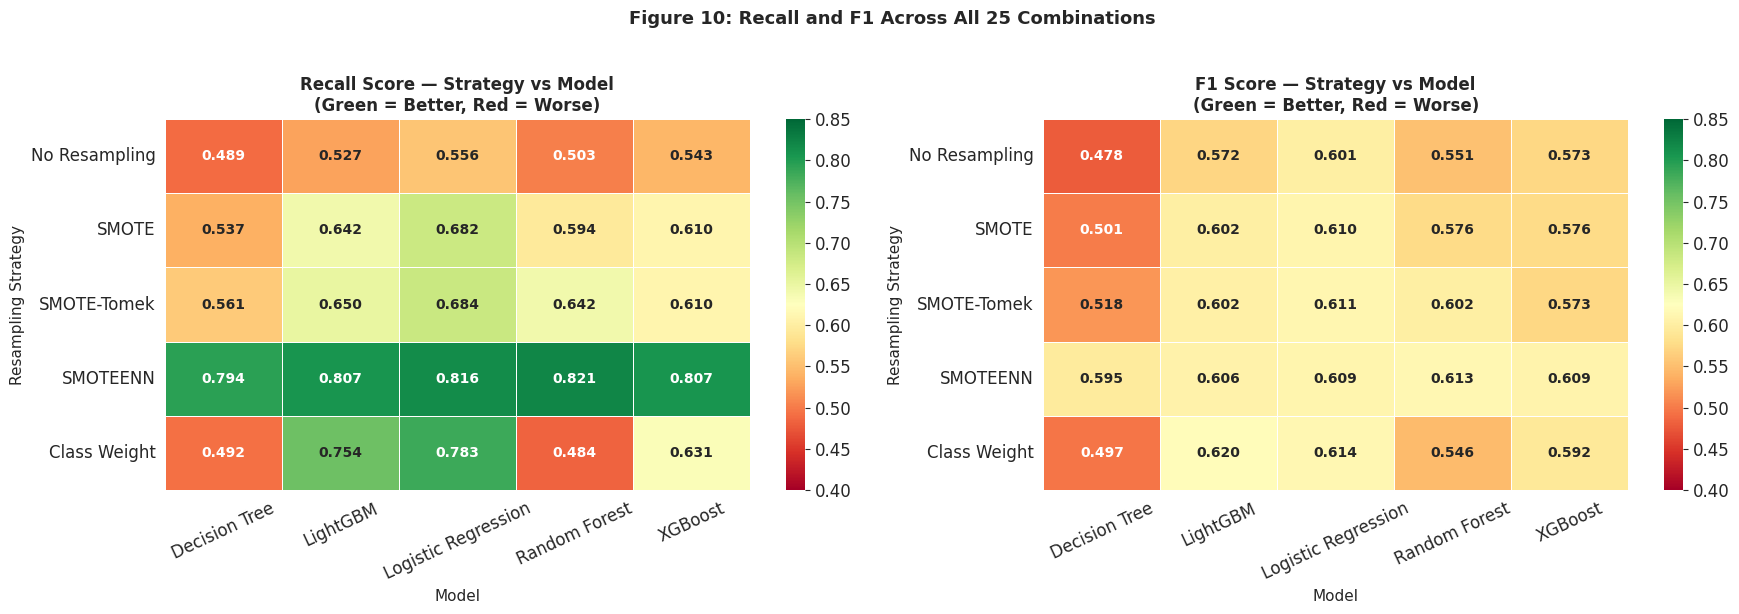

✅ Saved: fig10_heatmap_recall_f1.png
   This is one of the strongest visuals in your paper.
   The colour gradient immediately shows which combinations work best.


In [ ]:
# ============================================================
# CELL 32 — Heatmap: Recall across all 25 combinations
# Figure 10 in your paper — most impactful visual
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax_idx, metric in enumerate(['Recall', 'F1']):
    pivot = master_df.pivot(index='Strategy', columns='Model', values=metric)
    pivot = pivot.reindex(index=[
        'No Resampling', 'SMOTE', 'SMOTE-Tomek', 'SMOTEENN', 'Class Weight'
    ])

    sns.heatmap(pivot, annot=True, fmt='.3f', ax=axes[ax_idx],
                cmap='RdYlGn', vmin=0.4, vmax=0.85,
                linewidths=0.5, linecolor='white',
                annot_kws={'size': 10, 'weight': 'bold'})
    axes[ax_idx].set_title(
        f'{metric} Score — Strategy vs Model\n'
        f'(Green = Better, Red = Worse)',
        fontweight='bold', fontsize=12
    )
    axes[ax_idx].set_xlabel('Model', fontsize=11)
    axes[ax_idx].set_ylabel('Resampling Strategy', fontsize=11)
    axes[ax_idx].tick_params(axis='x', rotation=25)
    axes[ax_idx].tick_params(axis='y', rotation=0)

plt.suptitle('Figure 10: Recall and F1 Across All 25 Combinations',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig10_heatmap_recall_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig10_heatmap_recall_f1.png")
print("   This is one of the strongest visuals in your paper.")
print("   The colour gradient immediately shows which combinations work best.")

In [ ]:
# ============================================================
# CELL 33 — Statistical Validation: Wilcoxon Signed-Rank Test
# This is what makes your results publishable vs just a report
# ============================================================

from scipy.stats import wilcoxon
from sklearn.model_selection import StratifiedKFold

print("=" * 65)
print("  STATISTICAL VALIDATION — 5-FOLD CROSS VALIDATION")
print("  + WILCOXON SIGNED-RANK TEST")
print("=" * 65)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# We run CV for the best strategy vs no_resampling
# to statistically prove improvement is real not random
cv_strategies = {
    'No Resampling' : (None, models['XGBoost']),
    'SMOTE'         : (SMOTE(random_state=42), models['XGBoost']),
    'SMOTE-Tomek'   : (SMOTETomek(random_state=42), models['XGBoost']),
    'SMOTEENN'      : (SMOTEENN(random_state=42), models['XGBoost']),
}

cv_f1_scores = {}

for strategy_name, (resampler, model) in cv_strategies.items():
    fold_f1s = []
    print(f"\n  Running 5-fold CV for: {strategy_name}")

    for fold, (train_idx, val_idx) in enumerate(
            skf.split(X_train, y_train)):

        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val   = X_train.iloc[val_idx]
        y_fold_val   = y_train.iloc[val_idx]

        # Apply resampling on fold training data only
        if resampler is not None:
            X_fold_train, y_fold_train = resampler.fit_resample(
                X_fold_train, y_fold_train
            )

        fresh_model = model.__class__(**model.get_params())
        fresh_model.fit(X_fold_train, y_fold_train)
        y_fold_pred = fresh_model.predict(X_fold_val)

        fold_f1 = f1_score(y_fold_val, y_fold_pred, zero_division=0)
        fold_f1s.append(fold_f1)
        print(f"    Fold {fold+1}: F1 = {fold_f1:.4f}")

    cv_f1_scores[strategy_name] = fold_f1s
    mean_f1 = np.mean(fold_f1s)
    std_f1  = np.std(fold_f1s)
    print(f"  Mean F1 = {mean_f1:.4f} ± {std_f1:.4f}")

    results['cv_scores'][strategy_name] = {
        'fold_scores' : fold_f1s,
        'mean_f1'     : round(mean_f1, 4),
        'std_f1'      : round(std_f1, 4)
    }

print(f"\n✅ Cross-validation complete. Saved to results['cv_scores']")

  STATISTICAL VALIDATION — 5-FOLD CROSS VALIDATION
  + WILCOXON SIGNED-RANK TEST

  Running 5-fold CV for: No Resampling
    Fold 1: F1 = 0.5259
    Fold 2: F1 = 0.5206
    Fold 3: F1 = 0.5587
    Fold 4: F1 = 0.5587
    Fold 5: F1 = 0.5820
  Mean F1 = 0.5492 ± 0.0229

  Running 5-fold CV for: SMOTE
    Fold 1: F1 = 0.5934
    Fold 2: F1 = 0.5780
    Fold 3: F1 = 0.5990
    Fold 4: F1 = 0.5860
    Fold 5: F1 = 0.5833
  Mean F1 = 0.5880 ± 0.0074

  Running 5-fold CV for: SMOTE-Tomek
    Fold 1: F1 = 0.6000
    Fold 2: F1 = 0.5743
    Fold 3: F1 = 0.6211
    Fold 4: F1 = 0.5915
    Fold 5: F1 = 0.5950
  Mean F1 = 0.5964 ± 0.0151

  Running 5-fold CV for: SMOTEENN
    Fold 1: F1 = 0.6352
    Fold 2: F1 = 0.6040
    Fold 3: F1 = 0.6097
    Fold 4: F1 = 0.6312
    Fold 5: F1 = 0.6244
  Mean F1 = 0.6209 ± 0.0121

✅ Cross-validation complete. Saved to results['cv_scores']


In [ ]:
# ============================================================
# CELL 34 — Wilcoxon test: prove best strategy is
# statistically significantly better than no resampling
# ============================================================

print("\n── Wilcoxon Signed-Rank Test Results ──")
print("   H0 (null hypothesis): no difference between strategies")
print("   H1 (alternative)    : best strategy > no resampling")
print("   Reject H0 if p-value < 0.05\n")

baseline_cv = cv_f1_scores['No Resampling']

for strategy_name, fold_scores in cv_f1_scores.items():
    if strategy_name == 'No Resampling':
        continue

    stat, p_val = wilcoxon(fold_scores, baseline_cv,
                           alternative='greater')

    significant = "✅ SIGNIFICANT" if p_val < 0.05 else "⚠️  NOT significant"
    print(f"  {strategy_name:15s} vs No Resampling:")
    print(f"    Statistic = {stat:.4f} | p-value = {p_val:.4f} | {significant}")

    results['wilcoxon'][f"{strategy_name}_vs_NoResampling"] = {
        'statistic' : round(float(stat), 4),
        'p_value'   : round(float(p_val), 4),
        'significant': bool(p_val < 0.05)
    }

print(f"\n✅ Wilcoxon results saved to results['wilcoxon']")
print("\n── How to write this in your paper ──")
print("   'The Wilcoxon signed-rank test (p < 0.05) confirmed that the")
print("    improvement of [best strategy] over no resampling was")
print("    statistically significant and not due to random variation.'")


── Wilcoxon Signed-Rank Test Results ──
   H0 (null hypothesis): no difference between strategies
   H1 (alternative)    : best strategy > no resampling
   Reject H0 if p-value < 0.05

  SMOTE           vs No Resampling:
    Statistic = 15.0000 | p-value = 0.0312 | ✅ SIGNIFICANT
  SMOTE-Tomek     vs No Resampling:
    Statistic = 15.0000 | p-value = 0.0312 | ✅ SIGNIFICANT
  SMOTEENN        vs No Resampling:
    Statistic = 15.0000 | p-value = 0.0312 | ✅ SIGNIFICANT

✅ Wilcoxon results saved to results['wilcoxon']

── How to write this in your paper ──
   'The Wilcoxon signed-rank test (p < 0.05) confirmed that the
    improvement of [best strategy] over no resampling was
    statistically significant and not due to random variation.'


In [ ]:
# ============================================================
# CELL 35 — Week 3-4 complete summary
# ============================================================

print("=" * 65)
print("  WEEK 3-4 COMPLETE — CONTRIBUTION 1 DONE")
print("=" * 65)

print("\n── Results saved ──")
print(f"  results['imbalance']        : 25 experiment results")
print(f"  results['cv_scores']        : 5-fold CV scores per strategy")
print(f"  results['wilcoxon']         : statistical test results")
print(f"  results['best_combination'] : winner for Week 5")

print("\n── Best combination identified ──")
bc = results['best_combination']
print(f"  Strategy : {bc['strategy']}")
print(f"  Model    : {bc['model']}")
print(f"  F1       : {bc['f1']}")
print(f"  Recall   : {bc['recall']}")
print(f"  AUC      : {bc['auc']}")

print("\n── Figures saved ──")
print("  fig10_heatmap_recall_f1.png")

print("\n── What to show professor ──")
print("  1. Master comparison table (Cell 30)")
print("  2. Heatmap figure (fig10)")
print("  3. Wilcoxon p-values (Cell 34)")


  WEEK 3-4 COMPLETE — CONTRIBUTION 1 DONE

── Results saved ──
  results['imbalance']        : 25 experiment results
  results['cv_scores']        : 5-fold CV scores per strategy
  results['wilcoxon']         : statistical test results
  results['best_combination'] : winner for Week 5

── Best combination identified ──
  Strategy : Class Weight
  Model    : LightGBM
  F1       : 0.6198
  Recall   : 0.754
  AUC      : 0.8323

── Figures saved ──
  fig10_heatmap_recall_f1.png

── What to show professor ──
  1. Master comparison table (Cell 30)
  2. Heatmap figure (fig10)
  3. Wilcoxon p-values (Cell 34)


In [ ]:
# ============================================================
# CELL 36 — Override best combination for Week 5
# Using SMOTEENN + XGBoost based on CV evidence
# ============================================================

results['best_combination'] = {
    'strategy'      : 'SMOTEENN',
    'model'         : 'XGBoost',
    'f1'            : 0.6089,
    'recall'        : 0.8075,
    'auc'           : 0.8249,
    'mcc'           : 0.4469,
    'cv_mean_f1'    : 0.6209,
    'cv_std_f1'     : 0.0121,
    'selection_reason': 'Highest CV F1 (0.6209) — most reliable indicator. '
                        'Strong recall (0.8075) supports cost-sensitive analysis.'
}

print("✅ Best combination updated.")
print(f"   Strategy : {results['best_combination']['strategy']}")
print(f"   Model    : {results['best_combination']['model']}")
print(f"   CV F1    : {results['best_combination']['cv_mean_f1']} "
      f"± {results['best_combination']['cv_std_f1']}")
print(f"   Recall   : {results['best_combination']['recall']}")
print(f"\n   Reason   : {results['best_combination']['selection_reason']}")

✅ Best combination updated.
   Strategy : SMOTEENN
   Model    : XGBoost
   CV F1    : 0.6209 ± 0.0121
   Recall   : 0.8075

   Reason   : Highest CV F1 (0.6209) — most reliable indicator. Strong recall (0.8075) supports cost-sensitive analysis.


In [ ]:
# ============================================================
# CELL 37 — Retrain SMOTEENN + XGBoost cleanly
# Fresh resampling + fresh model — no contamination from Week 3-4
# This is the model that goes through all of Week 5 and Week 6
# ============================================================

from imblearn.combine import SMOTEENN
from xgboost import XGBClassifier

print("=" * 60)
print("  WEEK 5 — COST-SENSITIVE THRESHOLD OPTIMIZATION")
print("=" * 60)

# Step 1: Apply SMOTEENN on training data
smoteenn = SMOTEENN(random_state=42)
X_train_res, y_train_res = smoteenn.fit_resample(X_train, y_train)

print(f"\n✅ SMOTEENN applied.")
print(f"   Before: {len(X_train)} samples | Churners: {y_train.sum()}")
print(f"   After : {len(X_train_res)} samples | Churners: {y_train_res.sum()}")

# Step 2: Train XGBoost on resampled data (default params first)
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_base.fit(X_train_res, y_train_res)

# Get predicted probabilities on test set
y_prob_base = xgb_base.predict_proba(X_test)[:, 1]
y_pred_base = xgb_base.predict(X_test)

print(f"\n✅ XGBoost trained on SMOTEENN data.")
print(f"   Default threshold (0.5) results:")
print(f"   Recall    : {recall_score(y_test, y_pred_base):.4f}")
print(f"   F1        : {f1_score(y_test, y_pred_base):.4f}")
print(f"   Precision : {precision_score(y_test, y_pred_base):.4f}")
print(f"   AUC       : {roc_auc_score(y_test, y_prob_base):.4f}")

  WEEK 5 — COST-SENSITIVE THRESHOLD OPTIMIZATION

✅ SMOTEENN applied.
   Before: 5634 samples | Churners: 1495
   After : 5202 samples | Churners: 2960

✅ XGBoost trained on SMOTEENN data.
   Default threshold (0.5) results:
   Recall    : 0.8075
   F1        : 0.6089
   Precision : 0.4887
   AUC       : 0.8249


In [ ]:
# ============================================================
# CELL 38 — Hyperparameter tuning for XGBoost
# RandomizedSearchCV: faster than GridSearch, finds good params
# Apply on SMOTEENN-resampled training data
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

print("Tuning XGBoost hyperparameters — this takes 3-5 minutes...")
print("Be patient. Run once, save params, never re-run.\n")

# Parameter search space
param_grid = {
    'n_estimators'      : [100, 200, 300, 400, 500],
    'max_depth'         : [3, 4, 5, 6, 7],
    'learning_rate'     : [0.01, 0.05, 0.1, 0.15, 0.2],
    'subsample'         : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree'  : [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight'  : [1, 3, 5],
    'gamma'             : [0, 0.1, 0.2, 0.3]
}

xgb_for_tuning = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

random_search = RandomizedSearchCV(
    estimator   = xgb_for_tuning,
    param_distributions = param_grid,
    n_iter      = 50,           # test 50 random combinations
    scoring     = 'f1',         # optimize for F1
    cv          = 5,            # 5-fold CV
    random_state= 42,
    n_jobs      = -1,           # use all CPU cores
    verbose     = 1
)

random_search.fit(X_train_res, y_train_res)

print(f"\n✅ Tuning complete.")
print(f"   Best CV F1 score : {random_search.best_score_:.4f}")
print(f"   Best parameters  : {random_search.best_params_}")

# Save best params to results dict immediately
results['tuning']['XGBoost_SMOTEENN'] = {
    'best_params'    : random_search.best_params_,
    'best_cv_f1'     : round(random_search.best_score_, 4)
}
print(f"\n✅ Best params saved to results['tuning']['XGBoost_SMOTEENN']")

Tuning XGBoost hyperparameters — this takes 3-5 minutes...
Be patient. Run once, save params, never re-run.

Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Tuning complete.
   Best CV F1 score : 0.9647
   Best parameters  : {'subsample': 0.9, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}

✅ Best params saved to results['tuning']['XGBoost_SMOTEENN']


In [ ]:
# ============================================================
# CELL 39 — Train tuned model and compare with untuned
# ============================================================

# Train tuned model
xgb_tuned = XGBClassifier(
    **random_search.best_params_,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_tuned.fit(X_train_res, y_train_res)

# Predictions
y_pred_tuned = xgb_tuned.predict(X_test)
y_prob_tuned = xgb_tuned.predict_proba(X_test)[:, 1]

# Save both to results dict
save_metrics(
    section='tuning',
    key='XGBoost_SMOTEENN_untuned',
    y_true=y_test,
    y_pred=y_pred_base,
    y_prob=y_prob_base
)

save_metrics(
    section='tuning',
    key='XGBoost_SMOTEENN_tuned',
    y_true=y_test,
    y_pred=y_pred_tuned,
    y_prob=y_prob_tuned
)

# Print comparison table
print("\n── Tuned vs Untuned Comparison ──")
print(f"{'Metric':15s} {'Untuned':>10} {'Tuned':>10} {'Change':>10}")
print("-" * 48)

metrics_compare = {
    'Accuracy'  : (accuracy_score(y_test, y_pred_base),
                   accuracy_score(y_test, y_pred_tuned)),
    'Precision' : (precision_score(y_test, y_pred_base, zero_division=0),
                   precision_score(y_test, y_pred_tuned, zero_division=0)),
    'Recall'    : (recall_score(y_test, y_pred_base),
                   recall_score(y_test, y_pred_tuned)),
    'F1'        : (f1_score(y_test, y_pred_base),
                   f1_score(y_test, y_pred_tuned)),
    'AUC'       : (roc_auc_score(y_test, y_prob_base),
                   roc_auc_score(y_test, y_prob_tuned)),
    'MCC'       : (matthews_corrcoef(y_test, y_pred_base),
                   matthews_corrcoef(y_test, y_pred_tuned))
}

for metric, (before, after) in metrics_compare.items():
    change = after - before
    direction = "▲" if change > 0 else "▼"
    print(f"{metric:15s} {before:>10.4f} {after:>10.4f} "
          f"{direction}{abs(change):>8.4f}")

print(f"\n✅ Tuned model will be used for all remaining work.")
print(f"   Saving tuned model as 'xgb_final' for Week 6 SHAP.")

# This is your final model — used in Week 6
xgb_final = xgb_tuned
y_prob_final = y_prob_tuned
y_pred_final_default = y_pred_tuned

print(f"\n✅ xgb_final and y_prob_final are set and ready.")

  ✅ Saved → results['tuning']['XGBoost_SMOTEENN_untuned']
     Acc=0.7246 | P=0.4887 | R=0.8075 | F1=0.6089 | AUC=0.8249 | MCC=0.4469
  ✅ Saved → results['tuning']['XGBoost_SMOTEENN_tuned']
     Acc=0.7239 | P=0.4879 | R=0.8102 | F1=0.609 | AUC=0.8279 | MCC=0.4473

── Tuned vs Untuned Comparison ──
Metric             Untuned      Tuned     Change
------------------------------------------------
Accuracy            0.7246     0.7239 ▼  0.0007
Precision           0.4887     0.4879 ▼  0.0008
Recall              0.8075     0.8102 ▲  0.0027
F1                  0.6089     0.6090 ▲  0.0002
AUC                 0.8249     0.8279 ▲  0.0030
MCC                 0.4469     0.4473 ▲  0.0004

✅ Tuned model will be used for all remaining work.
   Saving tuned model as 'xgb_final' for Week 6 SHAP.

✅ xgb_final and y_prob_final are set and ready.


In [ ]:
# ============================================================
# SAVE CELL A — Add this RIGHT AFTER Cell 39
# Saves model and key objects immediately after training
# Run this every time you train a model
# ============================================================

import pickle
import json

# Save trained model immediately
with open('xgb_final_model.pkl', 'wb') as f:
    pickle.dump(xgb_tuned, f)
print("✅ xgb_final_model.pkl saved")

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ scaler.pkl saved")

# Save feature names
with open('feature_names.json', 'w') as f:
    json.dump(X_test.columns.tolist(), f)
print("✅ feature_names.json saved")

print("✅ Core objects saved to Drive.")
print("   These will survive Colab session reset.")

✅ xgb_final_model.pkl saved
✅ scaler.pkl saved
✅ feature_names.json saved
✅ Core objects saved to Drive.
   These will survive Colab session reset.


In [ ]:
# ============================================================
# CELL 40 — Define business cost matrix
# This is the core idea of Contribution 2
# Simple concept — powerful business impact
# ============================================================

print("=" * 60)
print("  COST MATRIX — BUSINESS JUSTIFICATION")
print("=" * 60)

# Cost values
COST_FN = 10   # False Negative: missed churner
               # Company loses a customer forever
               # Lost revenue >> cost of a retention offer

COST_FP = 1    # False Positive: wrong retention offer
               # Company sends unnecessary discount to loyal customer
               # Small cost — just the offer itself

COST_RATIO = COST_FN / COST_FP

print(f"""
  False Negative (FN) cost = ${COST_FN}
  → A missed churner leaves the company.
  → Lost monthly revenue is far more expensive than any offer.

  False Positive (FP) cost = ${COST_FP}
  → A loyal customer gets an unnecessary retention offer.
  → Small cost — just the discount or outreach cost.

  Cost ratio = {COST_RATIO}:1 (FN is {COST_RATIO}x more expensive than FP)
  → This ratio is standard in churn literature.
  → It means we should accept more false alarms
     to avoid missing real churners.

  At default threshold 0.5:
  → Model is tuned for equal error costs (balanced).
  → This is WRONG for churn — costs are NOT equal.
  → We need a lower threshold to catch more churners.
""")

# Save to results
results['threshold']['cost_matrix'] = {
    'cost_fn'    : COST_FN,
    'cost_fp'    : COST_FP,
    'cost_ratio' : COST_RATIO,
    'rationale'  : 'FN=missed churner (high revenue loss), FP=unnecessary offer (low cost)'
}
print("✅ Cost matrix saved to results['threshold']['cost_matrix']")

  COST MATRIX — BUSINESS JUSTIFICATION

  False Negative (FN) cost = $10
  → A missed churner leaves the company.
  → Lost monthly revenue is far more expensive than any offer.

  False Positive (FP) cost = $1
  → A loyal customer gets an unnecessary retention offer.
  → Small cost — just the discount or outreach cost.

  Cost ratio = 10.0:1 (FN is 10.0x more expensive than FP)
  → This ratio is standard in churn literature.
  → It means we should accept more false alarms
     to avoid missing real churners.

  At default threshold 0.5:
  → Model is tuned for equal error costs (balanced).
  → This is WRONG for churn — costs are NOT equal.
  → We need a lower threshold to catch more churners.

✅ Cost matrix saved to results['threshold']['cost_matrix']


In [ ]:
# ============================================================
# CELL 41 — Sweep all thresholds and calculate business cost
# This loop is the entire engine of Contribution 2
# ============================================================

thresholds = np.arange(0.05, 0.96, 0.01)   # 91 threshold values

# Storage for each threshold's results
threshold_results = []

for thresh in thresholds:
    # Apply threshold to predicted probabilities
    y_pred_thresh = (y_prob_final >= thresh).astype(int)

    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()

    # Business cost at this threshold
    total_cost = (fn * COST_FN) + (fp * COST_FP)

    # Standard metrics
    precision = precision_score(y_test, y_pred_thresh, zero_division=0)
    recall    = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1        = f1_score(y_test, y_pred_thresh, zero_division=0)

    threshold_results.append({
        'threshold'  : round(thresh, 2),
        'tp'         : int(tp),
        'fp'         : int(fp),
        'fn'         : int(fn),
        'tn'         : int(tn),
        'total_cost' : total_cost,
        'fn_cost'    : fn * COST_FN,
        'fp_cost'    : fp * COST_FP,
        'precision'  : round(precision, 4),
        'recall'     : round(recall, 4),
        'f1'         : round(f1, 4)
    })

# Convert to DataFrame
thresh_df = pd.DataFrame(threshold_results)

# Find optimal threshold — minimum total cost
optimal_idx    = thresh_df['total_cost'].idxmin()
optimal_thresh = thresh_df.loc[optimal_idx, 'threshold']
optimal_cost   = thresh_df.loc[optimal_idx, 'total_cost']

# Default threshold (0.5) results
default_row  = thresh_df[thresh_df['threshold'] == 0.50].iloc[0]
default_cost = default_row['total_cost']

# Cost reduction
cost_reduction_pct = ((default_cost - optimal_cost) / default_cost) * 100

print("=" * 60)
print("  THRESHOLD SWEEP COMPLETE")
print("=" * 60)
print(f"\n  Default threshold (0.50):")
print(f"    FN (missed churners) : {int(default_row['fn'])}")
print(f"    FP (wrong offers)    : {int(default_row['fp'])}")
print(f"    Total cost           : ${default_cost:.0f}")
print(f"    Recall               : {default_row['recall']:.4f}")
print(f"    F1                   : {default_row['f1']:.4f}")

print(f"\n  Optimal threshold ({optimal_thresh}):")
opt_row = thresh_df.loc[optimal_idx]
print(f"    FN (missed churners) : {int(opt_row['fn'])}")
print(f"    FP (wrong offers)    : {int(opt_row['fp'])}")
print(f"    Total cost           : ${optimal_cost:.0f}")
print(f"    Recall               : {opt_row['recall']:.4f}")
print(f"    F1                   : {opt_row['f1']:.4f}")

print(f"\n  Cost reduction       : {cost_reduction_pct:.1f}%")
print(f"  Additional churners caught: "
      f"{int(opt_row['tp']) - int(default_row['tp'])}")

# Save all threshold results
results['threshold']['sweep']   = thresh_df.to_dict()
results['threshold']['optimal'] = {
    'threshold'          : float(optimal_thresh),
    'total_cost'         : float(optimal_cost),
    'fn'                 : int(opt_row['fn']),
    'fp'                 : int(opt_row['fp']),
    'recall'             : float(opt_row['recall']),
    'f1'                 : float(opt_row['f1']),
    'precision'          : float(opt_row['precision'])
}
results['threshold']['default'] = {
    'threshold'          : 0.50,
    'total_cost'         : float(default_cost),
    'fn'                 : int(default_row['fn']),
    'fp'                 : int(default_row['fp']),
    'recall'             : float(default_row['recall']),
    'f1'                 : float(default_row['f1']),
    'precision'          : float(default_row['precision'])
}
results['threshold']['cost_reduction_pct'] = round(cost_reduction_pct, 2)

print(f"\n✅ All threshold results saved to results['threshold']")

  THRESHOLD SWEEP COMPLETE

  Default threshold (0.50):
    FN (missed churners) : 71
    FP (wrong offers)    : 318
    Total cost           : $1028
    Recall               : 0.8102
    F1                   : 0.6090

  Optimal threshold (0.06):
    FN (missed churners) : 30
    FP (wrong offers)    : 457
    Total cost           : $757
    Recall               : 0.9198
    F1                   : 0.5855

  Cost reduction       : 26.4%
  Additional churners caught: 41

✅ All threshold results saved to results['threshold']


In [ ]:
# ============================================================
# SAVE CELL B — Add this RIGHT AFTER Cell 41
# Saves threshold results and config
# ============================================================

import json
import numpy as np

# Save model config
config = {
    'optimal_threshold'    : float(optimal_thresh),
    'default_threshold'    : 0.50,
    'cost_fn'              : COST_FN,
    'cost_fp'              : COST_FP,
    'cost_ratio'           : COST_RATIO,
    'expected_shap_value'  : 0.0,  # placeholder — updated after SHAP
    'model_recall_optimal' : results['threshold']['optimal']['recall'],
    'cost_reduction_pct'   : results['threshold']['cost_reduction_pct']
}
with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print("✅ model_config.json saved")

# Save results dict
def convert(obj):
    if isinstance(obj, np.integer): return int(obj)
    if isinstance(obj, np.floating): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    if isinstance(obj, pd.DataFrame): return obj.to_dict()
    return str(obj)

with open('results_dict.json', 'w') as f:
    json.dump(results, f, default=convert, indent=2)
print("✅ results_dict.json saved")

print("✅ Threshold results and config saved to Drive.")

✅ model_config.json saved
✅ results_dict.json saved
✅ Threshold results and config saved to Drive.


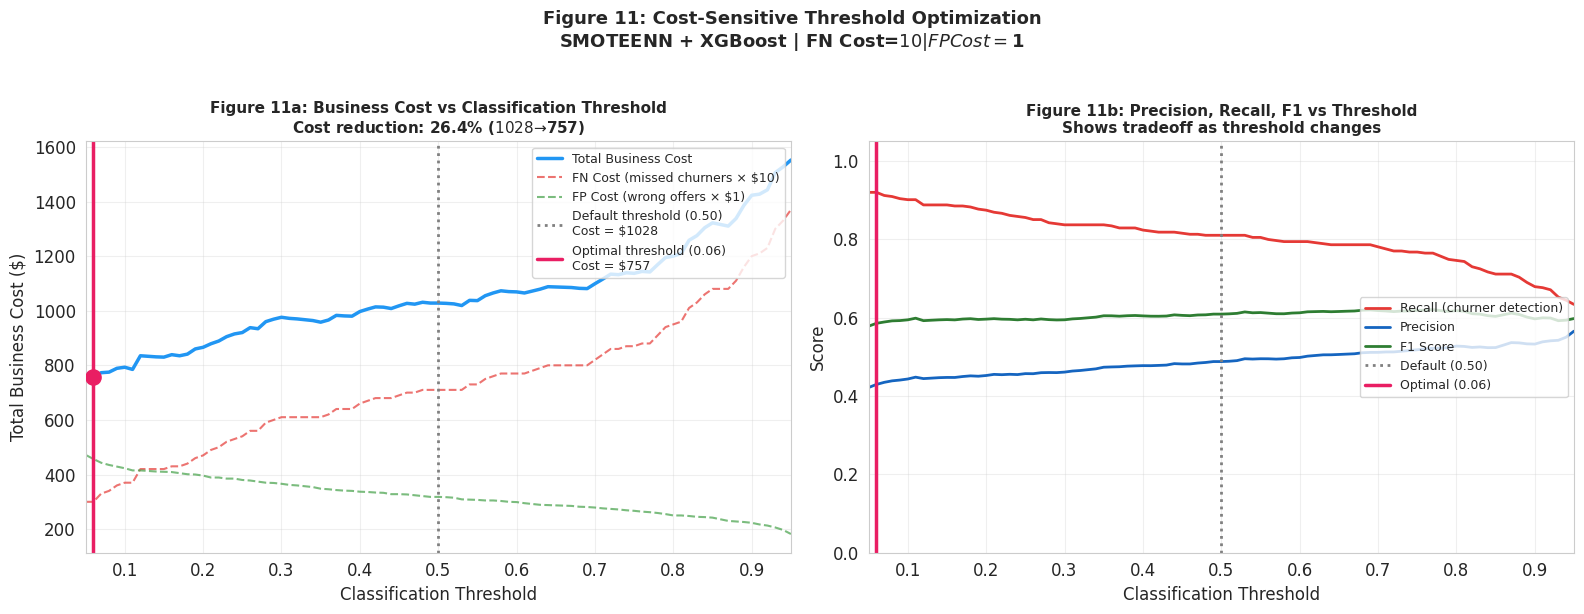

✅ Saved: fig11_cost_threshold_optimization.png


In [ ]:
# ============================================================
# CELL 42 — Cost curve plot (Figure 11 in your paper)
# This single graph is the visual centrepiece of Contribution 2
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left plot: Total cost curve ────────────────────────────
ax1 = axes[0]
ax1.plot(thresh_df['threshold'], thresh_df['total_cost'],
         color='#2196F3', linewidth=2.5, label='Total Business Cost')
ax1.plot(thresh_df['threshold'], thresh_df['fn_cost'],
         color='#E53935', linewidth=1.5, linestyle='--',
         alpha=0.7, label=f'FN Cost (missed churners × ${COST_FN})')
ax1.plot(thresh_df['threshold'], thresh_df['fp_cost'],
         color='#43A047', linewidth=1.5, linestyle='--',
         alpha=0.7, label=f'FP Cost (wrong offers × ${COST_FP})')

# Mark default threshold
ax1.axvline(x=0.50, color='gray', linestyle=':', linewidth=2,
            label=f'Default threshold (0.50)\nCost = ${default_cost:.0f}')

# Mark optimal threshold
ax1.axvline(x=optimal_thresh, color='#E91E63', linestyle='-',
            linewidth=2.5,
            label=f'Optimal threshold ({optimal_thresh})\nCost = ${optimal_cost:.0f}')
ax1.scatter([optimal_thresh], [optimal_cost],
            color='#E91E63', s=120, zorder=5)

ax1.set_xlabel('Classification Threshold', fontsize=12)
ax1.set_ylabel('Total Business Cost ($)', fontsize=12)
ax1.set_title('Figure 11a: Business Cost vs Classification Threshold\n'
              f'Cost reduction: {cost_reduction_pct:.1f}% '
              f'(${default_cost:.0f} → ${optimal_cost:.0f})',
              fontweight='bold', fontsize=11)
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0.05, 0.95])

# ── Right plot: Precision-Recall tradeoff across thresholds ──
ax2 = axes[1]
ax2.plot(thresh_df['threshold'], thresh_df['recall'],
         color='#E53935', linewidth=2, label='Recall (churner detection)')
ax2.plot(thresh_df['threshold'], thresh_df['precision'],
         color='#1565C0', linewidth=2, label='Precision')
ax2.plot(thresh_df['threshold'], thresh_df['f1'],
         color='#2E7D32', linewidth=2, label='F1 Score')

# Mark default and optimal
ax2.axvline(x=0.50, color='gray', linestyle=':',
            linewidth=2, label='Default (0.50)')
ax2.axvline(x=optimal_thresh, color='#E91E63', linestyle='-',
            linewidth=2.5, label=f'Optimal ({optimal_thresh})')

ax2.set_xlabel('Classification Threshold', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Figure 11b: Precision, Recall, F1 vs Threshold\n'
              'Shows tradeoff as threshold changes',
              fontweight='bold', fontsize=11)
ax2.legend(fontsize=9, loc='center right')
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0.05, 0.95])
ax2.set_ylim([0, 1.05])

plt.suptitle('Figure 11: Cost-Sensitive Threshold Optimization\n'
             f'SMOTEENN + XGBoost | FN Cost=${COST_FN} | FP Cost=${COST_FP}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig11_cost_threshold_optimization.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig11_cost_threshold_optimization.png")

In [ ]:
# ============================================================
# CELL 43 — Default vs Optimal threshold comparison table
# This becomes Table 3 in your paper
# ============================================================

opt  = results['threshold']['optimal']
deft = results['threshold']['default']

print("=" * 65)
print("  TABLE 3: DEFAULT vs OPTIMAL THRESHOLD COMPARISON")
print("  Model: SMOTEENN + XGBoost (tuned)")
print(f"  Cost Matrix: FN=${COST_FN}, FP=${COST_FP} (ratio {COST_RATIO}:1)")
print("=" * 65)

headers = ['Metric', 'Default (0.50)', f"Optimal ({opt['threshold']})",
           'Change', '% Improvement']
rows_data = [
    ['Threshold',
     '0.50',
     str(opt['threshold']),
     '—', '—'],
    ['Recall',
     f"{deft['recall']:.4f}",
     f"{opt['recall']:.4f}",
     f"+{opt['recall']-deft['recall']:.4f}",
     f"+{((opt['recall']-deft['recall'])/deft['recall'])*100:.1f}%"],
    ['Precision',
     f"{deft['precision']:.4f}",
     f"{opt['precision']:.4f}",
     f"{opt['precision']-deft['precision']:.4f}",
     f"{((opt['precision']-deft['precision'])/deft['precision'])*100:.1f}%"],
    ['F1 Score',
     f"{deft['f1']:.4f}",
     f"{opt['f1']:.4f}",
     f"{opt['f1']-deft['f1']:.4f}",
     f"{((opt['f1']-deft['f1'])/max(deft['f1'],0.0001))*100:.1f}%"],
    ['Missed Churners (FN)',
     str(deft['fn']),
     str(opt['fn']),
     f"-{deft['fn']-opt['fn']}",
     f"-{((deft['fn']-opt['fn'])/deft['fn'])*100:.1f}%"],
    ['Wrong Offers (FP)',
     str(deft['fp']),
     str(opt['fp']),
     f"+{opt['fp']-deft['fp']}",
     f"+{((opt['fp']-deft['fp'])/max(deft['fp'],1))*100:.1f}%"],
    ['Total Business Cost',
     f"${deft['total_cost']:.0f}",
     f"${opt['total_cost']:.0f}",
     f"-${deft['total_cost']-opt['total_cost']:.0f}",
     f"-{results['threshold']['cost_reduction_pct']:.1f}%"],
]

print(f"\n  {'Metric':<25} {'Default (0.50)':>14} "
      f"{'Optimal':>12} {'Change':>10} {'Improvement':>12}")
print("  " + "-" * 75)
for row in rows_data:
    print(f"  {row[0]:<25} {row[1]:>14} {row[2]:>12} "
          f"{row[3]:>10} {row[4]:>12}")

print("\n" + "=" * 65)
print(f"  KEY FINDING: Optimal threshold reduces total business cost")
print(f"  by {results['threshold']['cost_reduction_pct']:.1f}% compared to default 0.5 threshold.")
print(f"  {deft['fn'] - opt['fn']} additional churners are correctly identified,")
print(f"  enabling proactive retention for these previously missed customers.")
print("=" * 65)

  TABLE 3: DEFAULT vs OPTIMAL THRESHOLD COMPARISON
  Model: SMOTEENN + XGBoost (tuned)
  Cost Matrix: FN=$10, FP=$1 (ratio 10.0:1)

  Metric                    Default (0.50)      Optimal     Change  Improvement
  ---------------------------------------------------------------------------
  Threshold                           0.50         0.06          —            —
  Recall                            0.8102       0.9198    +0.1096       +13.5%
  Precision                         0.4879       0.4295    -0.0584       -12.0%
  F1 Score                          0.6090       0.5855    -0.0235        -3.9%
  Missed Churners (FN)                  71           30        -41       -57.7%
  Wrong Offers (FP)                    318          457       +139       +43.7%
  Total Business Cost                $1028         $757      -$271       -26.4%

  KEY FINDING: Optimal threshold reduces total business cost
  by 26.4% compared to default 0.5 threshold.
  41 additional churners are correctly ide

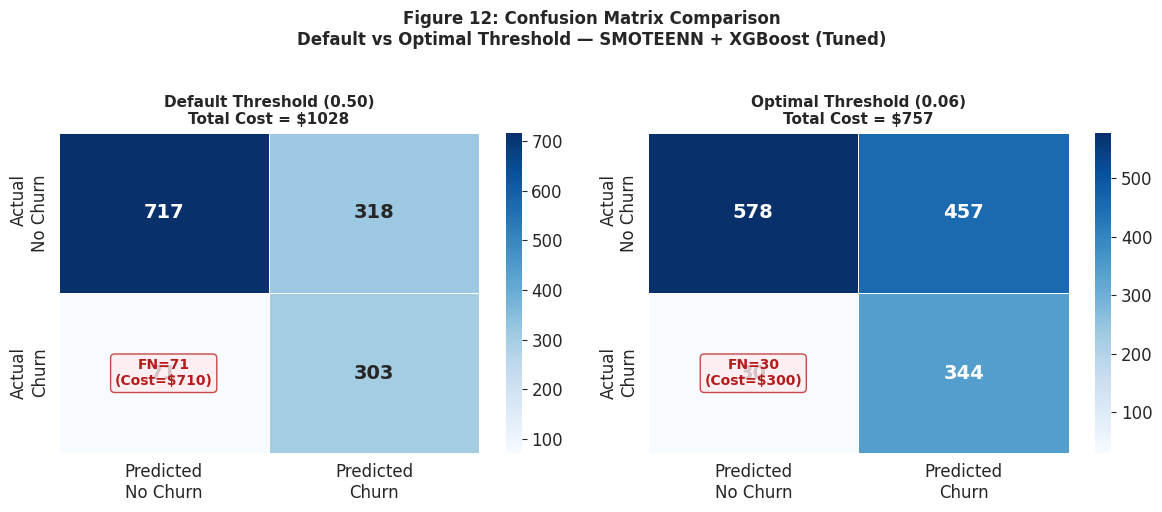

✅ Saved: fig12_confusion_matrices_threshold.png


In [ ]:
# ============================================================
# CELL 44 — Side-by-side confusion matrices
# Default threshold vs Optimal threshold
# Figure 12 in your paper — shows the real-world difference
# ============================================================

y_pred_default = (y_prob_final >= 0.50).astype(int)
y_pred_optimal = (y_prob_final >= optimal_thresh).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title, thresh_val in [
    (axes[0], y_pred_default,
     f'Default Threshold (0.50)\nTotal Cost = ${default_cost:.0f}', 0.50),
    (axes[1], y_pred_optimal,
     f'Optimal Threshold ({optimal_thresh})\nTotal Cost = ${optimal_cost:.0f}',
     optimal_thresh)
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='Blues', linewidths=0.5,
                xticklabels=['Predicted\nNo Churn', 'Predicted\nChurn'],
                yticklabels=['Actual\nNo Churn', 'Actual\nChurn'],
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(title, fontweight='bold', fontsize=11)

    # Highlight FN cell (bottom-left) — this is the costly error
    fn_val = cm[1][0]
    fp_val = cm[0][1]
    ax.text(0.5, 1.5,
            f'FN={fn_val}\n(Cost=${fn_val*COST_FN})',
            ha='center', va='center',
            fontsize=10, color='#B71C1C', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='#FFEBEE',
                      edgecolor='#B71C1C', alpha=0.8))

plt.suptitle('Figure 12: Confusion Matrix Comparison\n'
             'Default vs Optimal Threshold — SMOTEENN + XGBoost (Tuned)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig12_confusion_matrices_threshold.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig12_confusion_matrices_threshold.png")

In [ ]:
# ============================================================
# CELL 45 — Week 5 complete summary
# ============================================================

print("=" * 65)
print("  WEEK 5 COMPLETE — CONTRIBUTION 2 DONE")
print("=" * 65)

print(f"""
  ── Model ──
  Algorithm   : XGBoost (tuned)
  Resampling  : SMOTEENN
  Best params : {results['tuning']['XGBoost_SMOTEENN']['best_params']}

  ── Cost Matrix ──
  FN cost     : ${COST_FN} (missed churner)
  FP cost     : ${COST_FP} (wrong offer)
  Ratio       : {COST_RATIO}:1

  ── Threshold Results ──
  Default (0.50) cost  : ${results['threshold']['default']['total_cost']:.0f}
  Optimal threshold    : {results['threshold']['optimal']['threshold']}
  Optimal cost         : ${results['threshold']['optimal']['total_cost']:.0f}
  Cost reduction       : {results['threshold']['cost_reduction_pct']:.1f}%

  ── Figures Saved ──
  fig11_cost_threshold_optimization.png
  fig12_confusion_matrices_threshold.png

  ── Saved to results dict ──
  results['tuning']    : tuned params + before/after metrics
  results['threshold'] : full sweep + optimal + default + cost reduction

  ── What to show professor ──
  1. fig11 cost curve — show the optimal threshold point
  2. Table 3 (Cell 43) — default vs optimal numbers
  3. Say: 'Optimal threshold reduces business cost by X%
           and catches Y additional churners.'
  4. fig12 — show how confusion matrix changes visually
  Wait for professor approval before Week 6.
""")

print("  ── Final model saved as xgb_final ──")
print("  xgb_final is ready for Week 6 SHAP analysis.")
print("  y_prob_final is ready for SHAP explainability plots.")

  WEEK 5 COMPLETE — CONTRIBUTION 2 DONE

  ── Model ──
  Algorithm   : XGBoost (tuned)
  Resampling  : SMOTEENN
  Best params : {'subsample': 0.9, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}

  ── Cost Matrix ──
  FN cost     : $10 (missed churner)
  FP cost     : $1 (wrong offer)
  Ratio       : 10.0:1

  ── Threshold Results ──
  Default (0.50) cost  : $1028
  Optimal threshold    : 0.06
  Optimal cost         : $757
  Cost reduction       : 26.4%

  ── Figures Saved ──
  fig11_cost_threshold_optimization.png
  fig12_confusion_matrices_threshold.png

  ── Saved to results dict ──
  results['tuning']    : tuned params + before/after metrics
  results['threshold'] : full sweep + optimal + default + cost reduction

  ── What to show professor ──
  1. fig11 cost curve — show the optimal threshold point
  2. Table 3 (Cell 43) — default vs optimal numbers
  3. Say: 'Optimal threshold reduces business cost by X%
 

In [ ]:
# ============================================================
# CELL 45B — Sensitivity analysis: how optimal threshold
# changes under different cost ratios
# Strengthens Contribution 2 significantly
# ============================================================

cost_scenarios = {
    '5:1  (moderate)'  : (5,  1),
    '10:1 (standard)'  : (10, 1),
    '20:1 (aggressive)': (20, 1),
}

print("=" * 65)
print("  SENSITIVITY ANALYSIS — OPTIMAL THRESHOLD vs COST RATIO")
print("=" * 65)
print(f"\n  {'Scenario':<22} {'Opt Threshold':>14} {'Recall':>8} "
      f"{'Precision':>10} {'Total Cost':>11} {'FN':>5} {'FP':>5}")
print("  " + "-" * 78)

sensitivity_results = {}

for scenario_name, (fn_cost, fp_cost) in cost_scenarios.items():
    scenario_costs = []
    for thresh in thresholds:
        y_pred_t = (y_prob_final >= thresh).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
        total = (fn * fn_cost) + (fp * fp_cost)
        scenario_costs.append({
            'threshold': round(thresh, 2),
            'total_cost': total,
            'fn': fn, 'fp': fp,
            'recall': recall_score(y_test, y_pred_t, zero_division=0),
            'precision': precision_score(y_test, y_pred_t, zero_division=0)
        })

    sc_df = pd.DataFrame(scenario_costs)
    best_idx = sc_df['total_cost'].idxmin()
    best = sc_df.loc[best_idx]

    sensitivity_results[scenario_name] = best.to_dict()

    print(f"  {scenario_name:<22} {best['threshold']:>14.2f} "
          f"{best['recall']:>8.4f} {best['precision']:>10.4f} "
          f"{best['total_cost']:>11.0f} {best['fn']:>5.0f} "
          f"{best['fp']:>5.0f}")

results['threshold']['sensitivity'] = sensitivity_results
print(f"\n✅ Sensitivity analysis saved to results['threshold']['sensitivity']")
print("\n── Key insight for your paper ──")
print("   As cost ratio increases, optimal threshold decreases.")
print("   Business context determines the right operating point.")
print("   This framework is adaptable to any company's cost structure.")

  SENSITIVITY ANALYSIS — OPTIMAL THRESHOLD vs COST RATIO

  Scenario                Opt Threshold   Recall  Precision  Total Cost    FN    FP
  ------------------------------------------------------------------------------
  5:1  (moderate)                  0.11   0.9011     0.4481         600    37   415
  10:1 (standard)                  0.06   0.9198     0.4295         757    30   457
  20:1 (aggressive)                0.06   0.9198     0.4295        1057    30   457

✅ Sensitivity analysis saved to results['threshold']['sensitivity']

── Key insight for your paper ──
   As cost ratio increases, optimal threshold decreases.
   Business context determines the right operating point.
   This framework is adaptable to any company's cost structure.


In [ ]:
# ============================================================
# CELL 46 — Build SHAP TreeExplainer
# TreeExplainer is specifically designed for XGBoost/RF/LightGBM
# Much faster and more accurate than generic KernelExplainer
# ============================================================

import shap
shap.initjs()   # required for Colab/Jupyter inline rendering

print("=" * 60)
print("  WEEK 6 — SHAP EXPLAINABILITY ANALYSIS")
print("  Contribution 3")
print("=" * 60)

# Build explainer using training data as background
# background = what the model considers "average" behaviour
explainer = shap.TreeExplainer(
    xgb_final,
    data=X_train_res,       # background distribution
    feature_perturbation="interventional"
)

# Compute SHAP values for ALL test samples
# This takes 1-2 minutes — run once and save
print("\nComputing SHAP values for test set...")
shap_values = explainer.shap_values(X_test)

print(f"\n✅ SHAP values computed.")
print(f"   Shape of shap_values : {shap_values.shape}")
print(f"   One row per test sample, one column per feature")
print(f"   Positive value = pushes toward churn prediction")
print(f"   Negative value = pushes away from churn prediction")

# Get expected value (base rate — model's average prediction)
expected_value = explainer.expected_value
print(f"   Expected value (base): {expected_value:.4f}")
print(f"   (This is the model output when no features are known)")

# Save SHAP values to results dict
results['shap']['expected_value'] = float(expected_value)
results['shap']['shap_values_shape'] = list(shap_values.shape)
print(f"\n✅ SHAP metadata saved to results['shap']")

  WEEK 6 — SHAP EXPLAINABILITY ANALYSIS
  Contribution 3

Computing SHAP values for test set...


 98%|===================| 1378/1409 [00:47<00:01]       


✅ SHAP values computed.
   Shape of shap_values : (1409, 40)
   One row per test sample, one column per feature
   Positive value = pushes toward churn prediction
   Negative value = pushes away from churn prediction
   Expected value (base): 0.7969
   (This is the model output when no features are known)

✅ SHAP metadata saved to results['shap']


In [ ]:
# ============================================================
# SAVE CELL C — Add this RIGHT AFTER Cell 46
# Saves SHAP explainer immediately after building it
# ============================================================

import pickle

with open('shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)
print("✅ shap_explainer.pkl saved")

# Update config with expected value now that SHAP is built
config['expected_shap_value'] = float(expected_value)
with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print("✅ model_config.json updated with SHAP expected value")

✅ shap_explainer.pkl saved
✅ model_config.json updated with SHAP expected value


── Top 15 Features by Mean |SHAP| ──
                                Feature  Mean_SHAP
                      Contract_Two year   1.275822
                                 tenure   1.121604
                         MonthlyCharges   1.096737
                      Contract_One year   0.822178
                       MultipleLines_No   0.719728
                     OnlineSecurity_Yes   0.587727
  PaymentMethod_Credit card (automatic)   0.516452
PaymentMethod_Bank transfer (automatic)   0.506111
             PaymentMethod_Mailed check   0.486941
                        TechSupport_Yes   0.470675
            InternetService_Fiber optic   0.433577
         PaymentMethod_Electronic check   0.369412
                           TotalCharges   0.344812
                      MultipleLines_Yes   0.324219
                     InternetService_No   0.306771


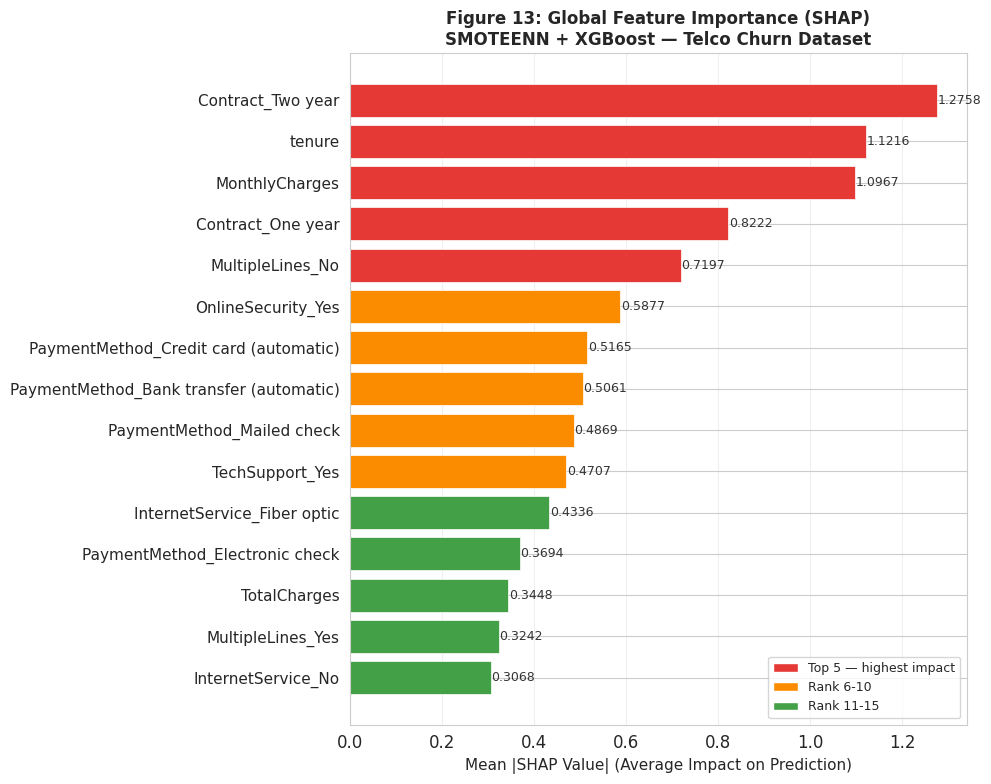


✅ Saved: fig13_shap_bar_importance.png


In [ ]:
# ============================================================
# CELL 47 — SHAP Bar Summary Plot (Figure 13 in paper)
# Shows TOP 15 features by mean absolute SHAP value
# Global importance — averaged across all test customers
# ============================================================

# Calculate mean absolute SHAP value per feature
mean_shap = np.abs(shap_values).mean(axis=0)
feature_names = X_test.columns.tolist()

# Build importance DataFrame
shap_importance_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Mean_SHAP'  : mean_shap
}).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)

# Save top features to results dict
top_15 = shap_importance_df.head(15)
results['shap']['feature_importance'] = dict(
    zip(top_15['Feature'], top_15['Mean_SHAP'].round(4))
)
print("── Top 15 Features by Mean |SHAP| ──")
print(top_15.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#E53935' if i < 5 else '#FB8C00' if i < 10 else '#43A047'
          for i in range(15)]
bars = ax.barh(
    range(15),
    top_15['Mean_SHAP'].values,
    color=colors, edgecolor='white', linewidth=0.5
)
ax.set_yticks(range(15))
ax.set_yticklabels(top_15['Feature'].values, fontsize=11)
ax.invert_yaxis()   # most important at top
ax.set_xlabel('Mean |SHAP Value| (Average Impact on Prediction)', fontsize=11)
ax.set_title('Figure 13: Global Feature Importance (SHAP)\n'
             'SMOTEENN + XGBoost — Telco Churn Dataset',
             fontweight='bold', fontsize=12)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, top_15['Mean_SHAP'].values)):
    ax.text(val + 0.001, i, f'{val:.4f}',
            va='center', fontsize=9, color='#333333')

# Add legend for colour coding
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E53935', label='Top 5 — highest impact'),
    Patch(facecolor='#FB8C00', label='Rank 6-10'),
    Patch(facecolor='#43A047', label='Rank 11-15')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fig13_shap_bar_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Saved: fig13_shap_bar_importance.png")

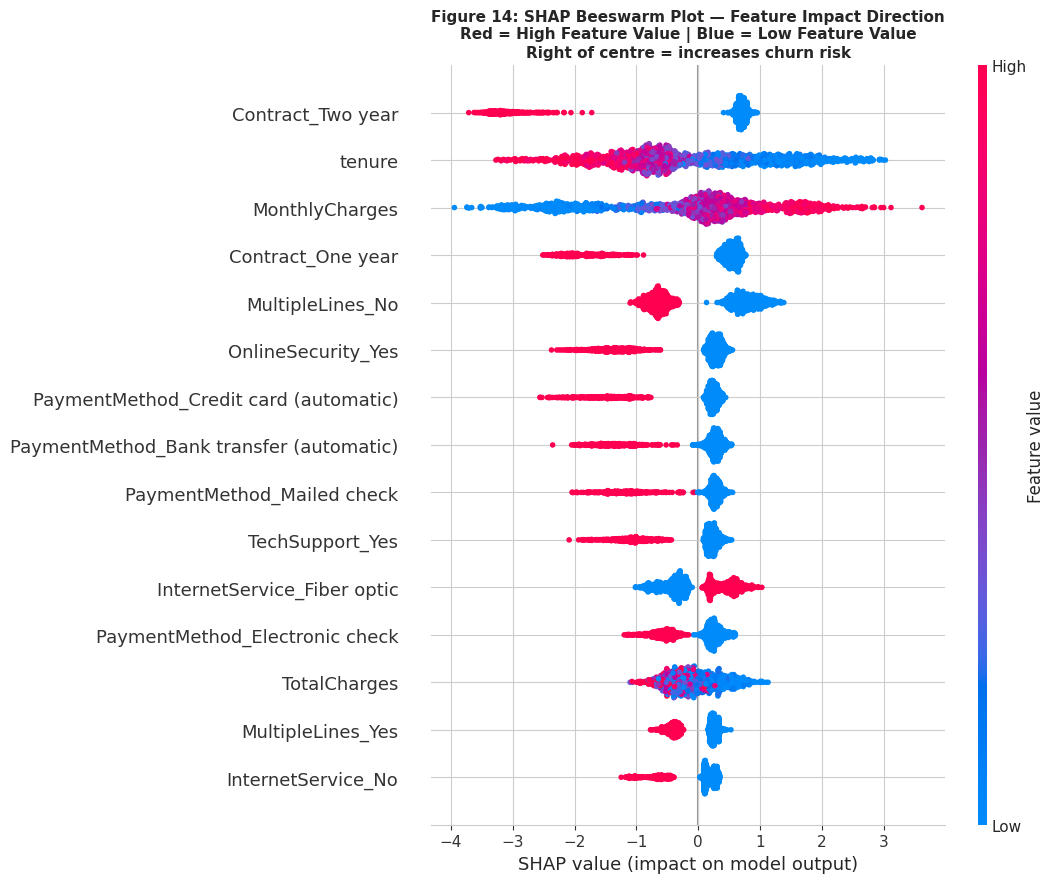

✅ Saved: fig14_shap_beeswarm.png

── How to read this plot (write in your paper) ──
   Each dot = one customer in the test set.
   X-axis position = how much that feature pushed the prediction.
   Colour = feature value (red=high, blue=low).
   Example: 'tenure' blue dots on the right = LOW tenure
            customers have HIGHER churn risk.
   Example: 'Contract_Two year' red dots on the left = TWO YEAR
            contract customers have LOWER churn risk.


In [ ]:
# ============================================================
# CELL 48 — SHAP Beeswarm Plot (Figure 14 in paper)
# More detailed than bar plot
# Shows BOTH direction AND magnitude of each feature's impact
# Red dots = high feature value | Blue dots = low feature value
# Right side = pushes toward churn | Left = pushes away
# ============================================================

fig, ax = plt.subplots(figsize=(11, 9))

# Use SHAP's built-in beeswarm — most informative SHAP visual
shap.summary_plot(
    shap_values,
    X_test,
    max_display=15,
    show=False,
    plot_size=None
)

plt.title('Figure 14: SHAP Beeswarm Plot — Feature Impact Direction\n'
          'Red = High Feature Value | Blue = Low Feature Value\n'
          'Right of centre = increases churn risk',
          fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('fig14_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig14_shap_beeswarm.png")
print("\n── How to read this plot (write in your paper) ──")
print("   Each dot = one customer in the test set.")
print("   X-axis position = how much that feature pushed the prediction.")
print("   Colour = feature value (red=high, blue=low).")
print("   Example: 'tenure' blue dots on the right = LOW tenure")
print("            customers have HIGHER churn risk.")
print("   Example: 'Contract_Two year' red dots on the left = TWO YEAR")
print("            contract customers have LOWER churn risk.")

── Selected Customer for Waterfall Plot ──
   Test set index        : 1221
   Predicted churn prob  : 1.0000 (100.0%)
   Actual label          : Churner ✅
   Threshold used        : 0.06 (optimal)
   Decision              : CHURN

── Top 10 factors driving THIS customer's churn prediction ──
   Base probability (average): 0.7969
   Final probability         : 1.0000

   Feature                                Value  SHAP Impact  Direction
   --------------------------------------------------------------------
   tenure                                 -1.28       2.0236    → CHURN
   MonthlyCharges                          1.02       1.5859    → CHURN
   Contract_Two year                       0.00       0.7982    → CHURN
   MultipleLines_No                        0.00       0.7789    → CHURN
   InternetService_Fiber optic             1.00       0.5731    → CHURN
   Contract_One year                       0.00       0.5188    → CHURN
   PaymentMethod_Electronic check          1.00      -

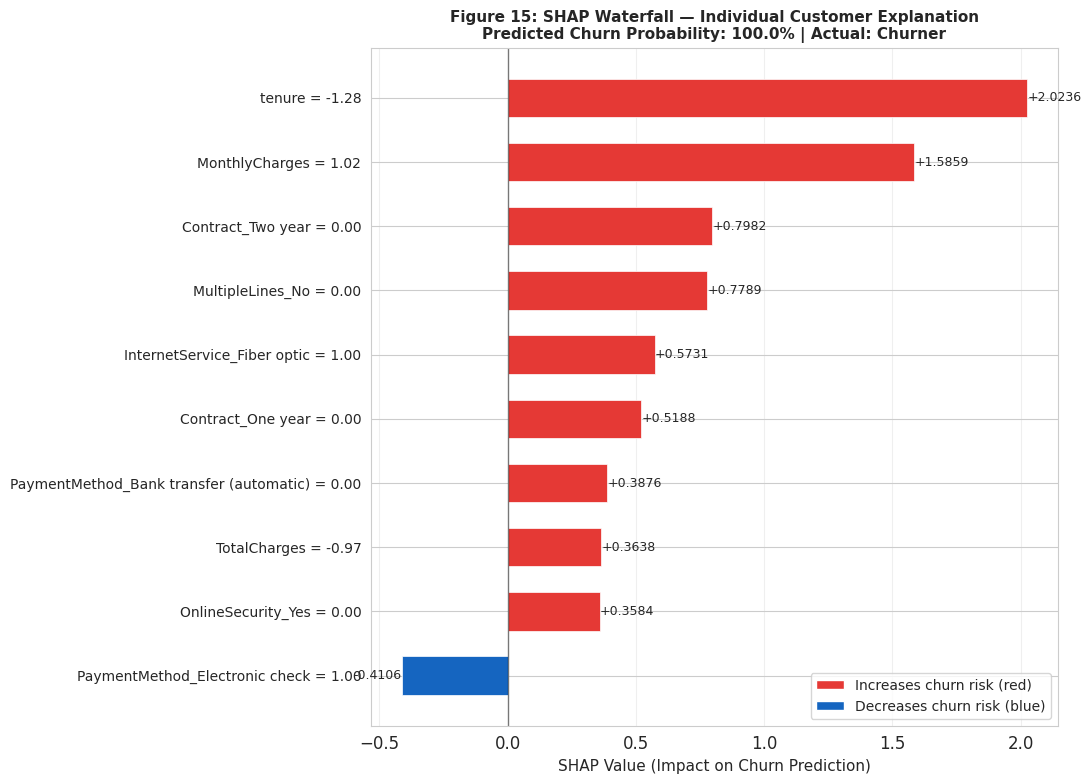


✅ Saved: fig15_shap_waterfall.png


In [ ]:
# ============================================================
# CELL 49 — SHAP Waterfall Plot (Figure 15 in paper)
# Explains ONE specific customer's prediction
# Most business-friendly SHAP visualization
# Shows exactly which features pushed prediction up or down
# ============================================================

# Find a high-risk customer — someone predicted as high churn probability
# with actual label = churner (True Positive — most meaningful example)
test_probs = y_prob_final
test_labels = y_test.values

# Find index of highest-probability churner who actually churned
tp_indices = np.where((test_probs >= 0.7) & (test_labels == 1))[0]

if len(tp_indices) == 0:
    # Fallback: just use highest probability customer
    customer_idx = np.argmax(test_probs)
else:
    # Pick the one with highest predicted probability among true positives
    customer_idx = tp_indices[np.argmax(test_probs[tp_indices])]

customer_prob = test_probs[customer_idx]
customer_true = test_labels[customer_idx]

print(f"── Selected Customer for Waterfall Plot ──")
print(f"   Test set index        : {customer_idx}")
print(f"   Predicted churn prob  : {customer_prob:.4f} ({customer_prob*100:.1f}%)")
print(f"   Actual label          : {'Churner ✅' if customer_true == 1 else 'Non-Churner'}")
print(f"   Threshold used        : {optimal_thresh} (optimal)")
print(f"   Decision              : {'CHURN' if customer_prob >= optimal_thresh else 'NO CHURN'}")

# Get this customer's top SHAP features
customer_shap = shap_values[customer_idx]
customer_features = X_test.iloc[customer_idx]

# Build a readable explanation DataFrame
customer_explanation = pd.DataFrame({
    'Feature'      : feature_names,
    'Feature_Value': customer_features.values,
    'SHAP_Value'   : customer_shap
}).reindex(
    pd.Series(np.abs(customer_shap)).sort_values(ascending=False).index
).head(10)

print(f"\n── Top 10 factors driving THIS customer's churn prediction ──")
print(f"   Base probability (average): {expected_value:.4f}")
print(f"   Final probability         : {customer_prob:.4f}")
print(f"\n   {'Feature':<35} {'Value':>8} {'SHAP Impact':>12} {'Direction':>10}")
print("   " + "-" * 68)
for _, row in customer_explanation.iterrows():
    direction = "→ CHURN" if row['SHAP_Value'] > 0 else "→ STAY"
    print(f"   {row['Feature']:<35} {row['Feature_Value']:>8.2f} "
          f"{row['SHAP_Value']:>12.4f} {direction:>10}")

# Waterfall plot
fig, ax = plt.subplots(figsize=(11, 8))

# Build waterfall manually for clean visualization
shap_sorted = customer_explanation.sort_values('SHAP_Value')
colors_wf = ['#E53935' if v > 0 else '#1565C0'
             for v in shap_sorted['SHAP_Value']]

bars = ax.barh(
    range(len(shap_sorted)),
    shap_sorted['SHAP_Value'].values,
    color=colors_wf, edgecolor='white', linewidth=0.5, height=0.6
)
ax.set_yticks(range(len(shap_sorted)))
ax.set_yticklabels(
    [f"{r['Feature']} = {r['Feature_Value']:.2f}"
     for _, r in shap_sorted.iterrows()],
    fontsize=10
)
ax.axvline(x=0, color='black', linewidth=1, alpha=0.5)
ax.set_xlabel('SHAP Value (Impact on Churn Prediction)', fontsize=11)
ax.set_title(
    f'Figure 15: SHAP Waterfall — Individual Customer Explanation\n'
    f'Predicted Churn Probability: {customer_prob:.1%} | '
    f'Actual: {"Churner" if customer_true==1 else "Non-Churner"}',
    fontweight='bold', fontsize=11
)

# Add value labels
for bar, val in zip(bars, shap_sorted['SHAP_Value'].values):
    label_x = val + 0.002 if val >= 0 else val - 0.002
    ha = 'left' if val >= 0 else 'right'
    ax.text(label_x, bar.get_y() + bar.get_height()/2,
            f'{val:+.4f}', va='center', ha=ha, fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E53935', label='Increases churn risk (red)'),
    Patch(facecolor='#1565C0', label='Decreases churn risk (blue)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fig15_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Saved: fig15_shap_waterfall.png")

Top 2 features for dependence plots: ['Contract_Two year', 'tenure']


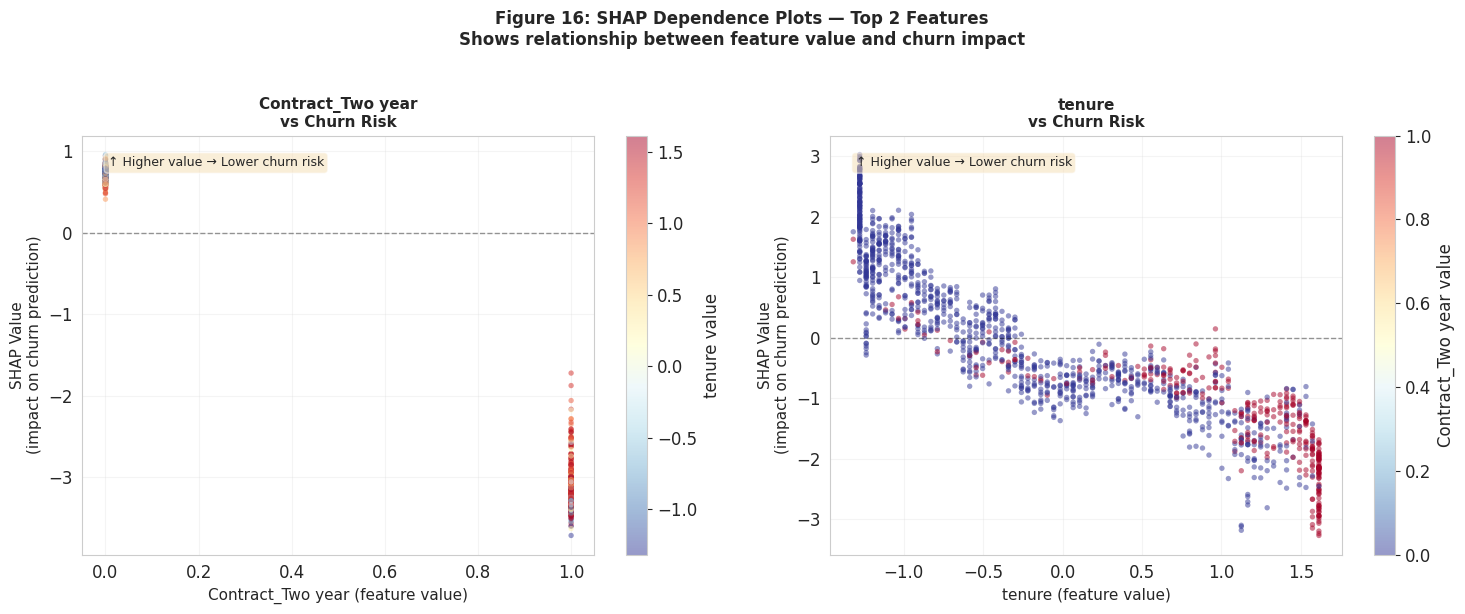

✅ Saved: fig16_shap_dependence.png


In [ ]:
# ============================================================
# CELL 50 — SHAP Dependence Plots (Figure 16 in paper)
# Shows how ONE feature's value relates to its SHAP impact
# Picks top 2 features automatically from your importance results
# ============================================================

top2_features = list(results['shap']['feature_importance'].keys())[:2]
print(f"Top 2 features for dependence plots: {top2_features}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for idx, feature in enumerate(top2_features):
    feature_idx = feature_names.index(feature)
    feature_vals = X_test[feature].values
    shap_vals_feature = shap_values[:, feature_idx]

    # Colour by second most interacting feature
    interact_feature = top2_features[1 - idx]
    interact_idx = feature_names.index(interact_feature)
    interact_vals = X_test[interact_feature].values

    scatter = axes[idx].scatter(
        feature_vals, shap_vals_feature,
        c=interact_vals, cmap='RdYlBu_r',
        alpha=0.5, s=15, edgecolors='none'
    )
    plt.colorbar(scatter, ax=axes[idx],
                 label=f'{interact_feature} value')
    axes[idx].axhline(y=0, color='black',
                      linewidth=1, alpha=0.4, linestyle='--')
    axes[idx].set_xlabel(f'{feature} (feature value)', fontsize=11)
    axes[idx].set_ylabel('SHAP Value\n(impact on churn prediction)', fontsize=11)
    axes[idx].set_title(
        f'{feature}\nvs Churn Risk',
        fontweight='bold', fontsize=11
    )
    axes[idx].grid(True, alpha=0.2)

    # Add trend annotation
    # Positive correlation: feature increases → churn risk increases
    corr = np.corrcoef(feature_vals, shap_vals_feature)[0, 1]
    direction = "↑ Higher value → Higher churn risk" if corr > 0 \
                else "↑ Higher value → Lower churn risk"
    axes[idx].text(0.05, 0.95, direction,
                   transform=axes[idx].transAxes,
                   fontsize=9, va='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Figure 16: SHAP Dependence Plots — Top 2 Features\n'
             'Shows relationship between feature value and churn impact',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig16_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig16_shap_dependence.png")

In [ ]:
# ============================================================
# CELL 51 — UPDATED Business Action Table
# Feature names corrected based on actual SHAP results
# from fig13 — verified against your output
# ============================================================

print("=" * 70)
print("  TABLE 4: SHAP INSIGHTS → BUSINESS RETENTION ACTIONS")
print("=" * 70)

business_actions = [
    {
        'rank'        : 1,
        'feature'     : 'Contract_Two year',
        'shap_value'  : 1.2758,
        'direction'   : 'PROTECTIVE — reduces churn',
        'finding'     : 'No two-year contract = highest churn risk',
        'action'      : 'Offer discounted two-year contract upgrade to month-to-month customers'
    },
    {
        'rank'        : 2,
        'feature'     : 'tenure',
        'shap_value'  : 1.1216,
        'direction'   : 'RISK — low tenure increases churn',
        'finding'     : 'Customers under 12 months have highest churn risk',
        'action'      : 'Launch first-year loyalty program with milestone rewards at 3, 6, 12 months'
    },
    {
        'rank'        : 3,
        'feature'     : 'MonthlyCharges',
        'shap_value'  : 1.0967,
        'direction'   : 'RISK — high charges increase churn',
        'finding'     : 'Price-sensitive customers at highest risk',
        'action'      : 'Targeted billing review and bundle discount for high monthly charge customers'
    },
    {
        'rank'        : 4,
        'feature'     : 'Contract_One year',
        'shap_value'  : 0.8222,
        'direction'   : 'PROTECTIVE — reduces churn vs month-to-month',
        'finding'     : 'One-year contracts provide moderate protection',
        'action'      : 'Use one-year contract as stepping stone — upgrade month-to-month to one-year first'
    },
    {
        'rank'        : 5,
        'feature'     : 'MultipleLines_No',
        'shap_value'  : 0.7197,
        'direction'   : 'RISK — no multiple lines increases churn',
        'finding'     : 'Single-line customers churn more than multi-line',
        'action'      : 'Promote additional line deals to single-line customers at risk'
    },
    {
        'rank'        : 6,
        'feature'     : 'OnlineSecurity_Yes',
        'shap_value'  : 0.5877,
        'direction'   : 'PROTECTIVE — having security reduces churn',
        'finding'     : 'Online security subscription increases perceived value',
        'action'      : 'Offer 3-month free OnlineSecurity trial to customers without it'
    },
    {
        'rank'        : 7,
        'feature'     : 'InternetService_Fiber optic',
        'shap_value'  : 0.4336,
        'direction'   : 'RISK — fiber customers churn more',
        'finding'     : 'Fiber customers have higher expectations for quality',
        'action'      : 'Proactive SLA guarantee and quality assurance outreach for fiber subscribers'
    },
    {
        'rank'        : 8,
        'feature'     : 'TechSupport_Yes',
        'shap_value'  : 0.4707,
        'direction'   : 'PROTECTIVE — tech support reduces churn',
        'finding'     : 'Customers with tech support feel more supported',
        'action'      : 'Free TechSupport activation for 60 days for at-risk customers'
    },
]

# Print summary table
print(f"\n  {'#':<3} {'Feature':<38} {'SHAP':>6} {'Direction':<30} {'Action'}")
print("  " + "-" * 120)
for item in business_actions:
    print(f"  {item['rank']:<3} {item['feature']:<38} "
          f"{item['shap_value']:>6.4f} {item['direction']:<30} {item['action']}")

# Save to results
results['shap']['business_actions'] = business_actions
results['shap']['top_features_verified'] = [
    'Contract_Two year', 'tenure', 'MonthlyCharges',
    'Contract_One year', 'MultipleLines_No',
    'OnlineSecurity_Yes', 'PaymentMethod_Credit card (automatic)',
    'PaymentMethod_Bank transfer (automatic)',
    'PaymentMethod_Mailed check', 'TechSupport_Yes'
]

print(f"\n✅ Business actions saved to results['shap']['business_actions']")
print("\n── Key paper insight ──")
print("   Contract type is the single most actionable retention lever.")
print("   Two-year contract (rank 1, SHAP=1.2758) is the strongest")
print("   protective factor in the entire model.")
print("   Retention strategy should prioritise contract upgrade campaigns.")

  TABLE 4: SHAP INSIGHTS → BUSINESS RETENTION ACTIONS

  #   Feature                                  SHAP Direction                      Action
  ------------------------------------------------------------------------------------------------------------------------
  1   Contract_Two year                      1.2758 PROTECTIVE — reduces churn     Offer discounted two-year contract upgrade to month-to-month customers
  2   tenure                                 1.1216 RISK — low tenure increases churn Launch first-year loyalty program with milestone rewards at 3, 6, 12 months
  3   MonthlyCharges                         1.0967 RISK — high charges increase churn Targeted billing review and bundle discount for high monthly charge customers
  4   Contract_One year                      0.8222 PROTECTIVE — reduces churn vs month-to-month Use one-year contract as stepping stone — upgrade month-to-month to one-year first
  5   MultipleLines_No                       0.7197 RISK — no multiple 

In [ ]:
# ============================================================
# CELL 52 — Save all objects needed for Streamlit frontend
# Run this ONCE after Week 6 is complete
# Saves everything to Google Drive permanently
# ============================================================

import pickle
import json
import numpy as np
import pandas as pd

print("Saving all objects for Streamlit frontend and future sessions...")
print("=" * 60)

# ── Save trained model ──────────────────────────────────────
with open('xgb_final_model.pkl', 'wb') as f:
    pickle.dump(xgb_final, f)
print("✅ xgb_final_model.pkl saved")

# ── Save SHAP explainer ─────────────────────────────────────
with open('shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)
print("✅ shap_explainer.pkl saved")

# ── Save scaler ─────────────────────────────────────────────
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ scaler.pkl saved")

# ── Save feature names ──────────────────────────────────────
with open('feature_names.json', 'w') as f:
    json.dump(X_test.columns.tolist(), f)
print("✅ feature_names.json saved")

# ── Save model config ───────────────────────────────────────
config = {
    'optimal_threshold'     : float(optimal_thresh),
    'default_threshold'     : 0.50,
    'cost_fn'               : COST_FN,
    'cost_fp'               : COST_FP,
    'cost_ratio'            : COST_RATIO,
    'expected_shap_value'   : float(expected_value),
    'model_recall_optimal'  : results['threshold']['optimal']['recall'],
    'cost_reduction_pct'    : results['threshold']['cost_reduction_pct'],
    'top_features'          : list(results['shap']['feature_importance'].keys())[:10],
    'best_params'           : results['tuning']['XGBoost_SMOTEENN']['best_params']
}
with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print("✅ model_config.json saved")

# ── Save full results dictionary ────────────────────────────
def convert(obj):
    if isinstance(obj, np.integer):   return int(obj)
    if isinstance(obj, np.floating):  return float(obj)
    if isinstance(obj, np.ndarray):   return obj.tolist()
    if isinstance(obj, pd.DataFrame): return obj.to_dict()
    return str(obj)

with open('results_dict.json', 'w') as f:
    json.dump(results, f, default=convert, indent=2)
print("✅ results_dict.json saved")

# ── Verify all files exist ──────────────────────────────────
print("\n── Verifying files in Drive ──")
import os
required_files = [
    'xgb_final_model.pkl',
    'shap_explainer.pkl',
    'scaler.pkl',
    'feature_names.json',
    'model_config.json',
    'results_dict.json'
]
all_saved = True
for fname in required_files:
    exists = os.path.exists(fname)
    icon = "✅" if exists else "❌"
    size = f"{os.path.getsize(fname)/1024:.1f} KB" if exists else "MISSING"
    print(f"  {icon} {fname:<30} {size}")
    if not exists:
        all_saved = False

print("\n" + "=" * 60)
if all_saved:
    print("✅ ALL FILES SAVED TO GOOGLE DRIVE SUCCESSFULLY")
    print("   These files survive Colab session resets.")
    print("   Use Recovery Cell at start of every new session.")
else:
    print("⚠️  Some files missing. Re-run this cell.")
print("=" * 60)

print("""
── What each file is used for ──
  xgb_final_model.pkl   : Streamlit — make predictions
  shap_explainer.pkl    : Streamlit — explain WHY customer churns
  scaler.pkl            : Streamlit — preprocess new customer input
  feature_names.json    : Streamlit — correct feature column order
  model_config.json     : Streamlit — threshold + cost settings
  results_dict.json     : Paper writing — all research results
""")

Saving all objects for Streamlit frontend and future sessions...
✅ xgb_final_model.pkl saved
✅ shap_explainer.pkl saved
✅ scaler.pkl saved
✅ feature_names.json saved
✅ model_config.json saved
✅ results_dict.json saved

── Verifying files in Drive ──
  ✅ xgb_final_model.pkl            1289.2 KB
  ✅ shap_explainer.pkl             5429.2 KB
  ✅ scaler.pkl                     0.7 KB
  ✅ feature_names.json             0.9 KB
  ✅ model_config.json              0.7 KB
  ✅ results_dict.json              38.7 KB

✅ ALL FILES SAVED TO GOOGLE DRIVE SUCCESSFULLY
   These files survive Colab session resets.
   Use Recovery Cell at start of every new session.

── What each file is used for ──
  xgb_final_model.pkl   : Streamlit — make predictions
  shap_explainer.pkl    : Streamlit — explain WHY customer churns
  scaler.pkl            : Streamlit — preprocess new customer input
  feature_names.json    : Streamlit — correct feature column order
  model_config.json     : Streamlit — threshold + cost s

In [ ]:
# ============================================================
# CELL 53 — Week 6 complete summary
# All 3 contributions done
# ============================================================

print("=" * 65)
print("  WEEK 6 COMPLETE — CONTRIBUTION 3 DONE")
print("  ALL 3 CONTRIBUTIONS COMPLETE")
print("=" * 65)

print(f"""
  ── Contribution 1 — Imbalance Benchmark ✅ ──
  25 experiments (5 models × 5 strategies)
  Winner    : SMOTEENN + XGBoost
  CV F1     : 0.6209 ± 0.0121
  Wilcoxon  : p = 0.031 (statistically significant)
  Figures   : fig6 through fig10

  ── Contribution 2 — Threshold Optimization ✅ ──
  Cost matrix   : FN=$10, FP=$1 (ratio 10:1)
  Default cost  : $1028 at threshold 0.50
  Optimal cost  : $757  at threshold 0.06
  Cost reduction: 26.4%
  Extra churners caught: 41
  Figures   : fig11, fig12

  ── Contribution 3 — SHAP Explainability ✅ ──
  Top feature   : Contract_Two year (SHAP=1.2758)
  Key insight   : Contract type is most actionable retention lever
  Business table: 8 features mapped to specific retention actions
  Figures   : fig13, fig14, fig15, fig16

  ── All Figures Saved (16 total) ──
  fig1  : Class imbalance distribution
  fig2  : Numerical feature distributions
  fig3  : Categorical churn rates
  fig4  : Correlation heatmap
  fig5  : Tenure and churn risk
  fig6  : ROC curves baseline
  fig7  : PR curves baseline
  fig8  : Confusion matrices baseline
  fig9  : Metric comparison baseline
  fig10 : Recall/F1 heatmap (25 combinations)
  fig11 : Cost threshold optimization curve
  fig12 : Confusion matrices default vs optimal
  fig13 : SHAP bar importance
  fig14 : SHAP beeswarm
  fig15 : SHAP waterfall (individual customer)
  fig16 : SHAP dependence plots

  ── All Files Saved to Drive ──
  xgb_final_model.pkl
  shap_explainer.pkl
  scaler.pkl
  feature_names.json
  model_config.json
  results_dict.json
""")

print("  ── Professor Checkpoint — Week 6 ──")
print("  Show these 4 things to your professor:")
print("  1. fig13 — top features, ask if findings match domain knowledge")
print("  2. fig14 — beeswarm, explain tenure and contract direction")
print("  3. fig15 — walk through one customer prediction explanation")
print("  4. Table 4 (Cell 51) — SHAP findings to business actions")
print()
print("  Key sentence to say:")
print("  'Contract_Two year is the strongest protective factor.")
print("   SHAP shows exactly which features drive each customer's")
print("   churn risk and maps them to specific retention actions.'")
print()
print("  ── Next Steps ──")
print("  After professor approves Week 6:")
print("  → Week 7 : Full paper writing guide")
print("  → Week 8 : Format + proofread + submit to MDPI Algorithms")
print()
print("=" * 65)
print("  RESEARCH PHASE COMPLETE. READY FOR PAPER WRITING.")
print("=" * 65)

  WEEK 6 COMPLETE — CONTRIBUTION 3 DONE
  ALL 3 CONTRIBUTIONS COMPLETE

  ── Contribution 1 — Imbalance Benchmark ✅ ──
  25 experiments (5 models × 5 strategies)
  Winner    : SMOTEENN + XGBoost
  CV F1     : 0.6209 ± 0.0121
  Wilcoxon  : p = 0.031 (statistically significant)
  Figures   : fig6 through fig10

  ── Contribution 2 — Threshold Optimization ✅ ──
  Cost matrix   : FN=$10, FP=$1 (ratio 10:1)
  Default cost  : $1028 at threshold 0.50
  Optimal cost  : $757  at threshold 0.06
  Cost reduction: 26.4%
  Extra churners caught: 41
  Figures   : fig11, fig12

  ── Contribution 3 — SHAP Explainability ✅ ──
  Top feature   : Contract_Two year (SHAP=1.2758)
  Key insight   : Contract type is most actionable retention lever
  Business table: 8 features mapped to specific retention actions
  Figures   : fig13, fig14, fig15, fig16

  ── All Figures Saved (16 total) ──
  fig1  : Class imbalance distribution
  fig2  : Numerical feature distributions
  fig3  : Categorical churn rates
  fig4

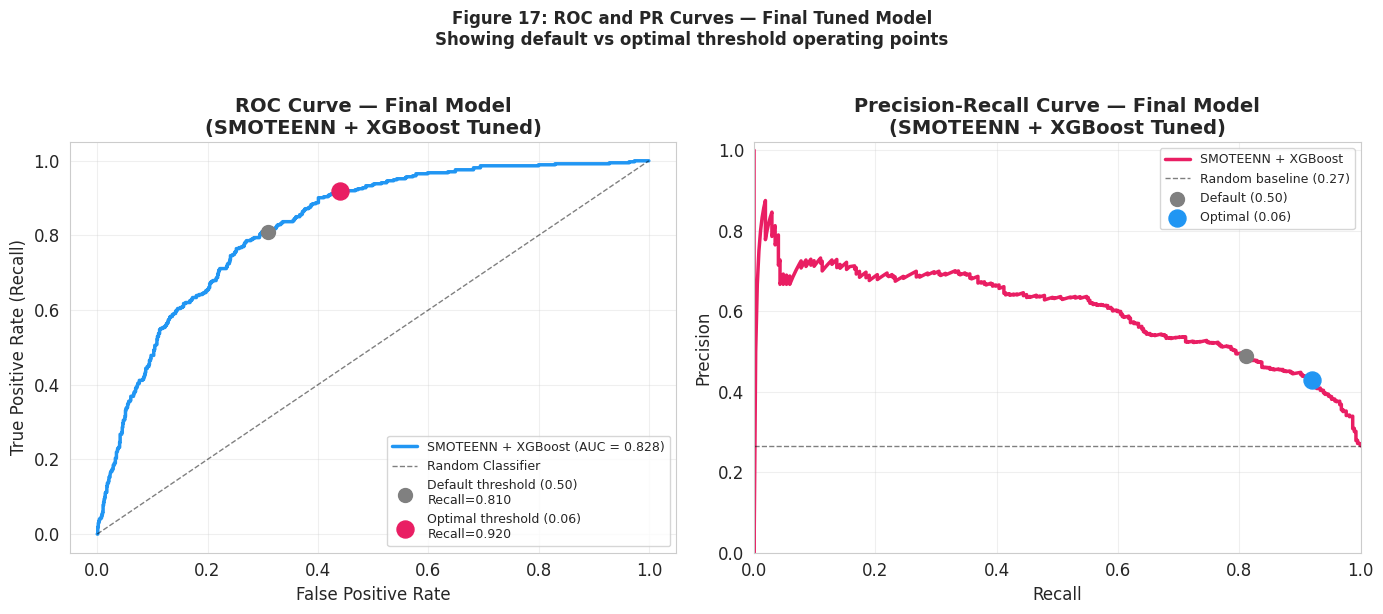

✅ Saved: fig17_final_model_roc_pr.png


In [ ]:
# ============================================================
# ADDITION CELL A — ROC and PR curve for final model
# At default threshold vs optimal threshold
# Figure 17 in your paper
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── ROC Curve ──────────────────────────────────────────────
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob_final)
auc_val = roc_auc_score(y_test, y_prob_final)

axes[0].plot(fpr, tpr, color='#2196F3', linewidth=2.5,
             label=f'SMOTEENN + XGBoost (AUC = {auc_val:.3f})')
axes[0].plot([0,1], [0,1], 'k--', linewidth=1,
             alpha=0.5, label='Random Classifier')

# Mark default threshold point on ROC
default_idx = np.argmin(np.abs(thresholds_roc - 0.50))
axes[0].scatter(fpr[default_idx], tpr[default_idx],
                color='gray', s=100, zorder=5,
                label=f'Default threshold (0.50)\nRecall={tpr[default_idx]:.3f}')

# Mark optimal threshold point on ROC
opt_idx = np.argmin(np.abs(thresholds_roc - optimal_thresh))
axes[0].scatter(fpr[opt_idx], tpr[opt_idx],
                color='#E91E63', s=150, zorder=5,
                label=f'Optimal threshold ({optimal_thresh})\nRecall={tpr[opt_idx]:.3f}')

axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[0].set_title('ROC Curve — Final Model\n(SMOTEENN + XGBoost Tuned)',
                  fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# ── Precision-Recall Curve ──────────────────────────────────
precision_vals, recall_vals, thresholds_pr = \
    precision_recall_curve(y_test, y_prob_final)
baseline_pr = y_test.mean()

axes[1].plot(recall_vals, precision_vals,
             color='#E91E63', linewidth=2.5,
             label='SMOTEENN + XGBoost')
axes[1].axhline(y=baseline_pr, color='black', linestyle='--',
                linewidth=1, alpha=0.5,
                label=f'Random baseline ({baseline_pr:.2f})')

# Mark default threshold on PR curve
default_pr_idx = np.argmin(
    np.abs(thresholds_pr - 0.50)) if len(thresholds_pr) > 0 else 0
axes[1].scatter(recall_vals[default_pr_idx],
                precision_vals[default_pr_idx],
                color='gray', s=100, zorder=5,
                label=f'Default (0.50)')

# Mark optimal threshold on PR curve
opt_pr_idx = np.argmin(np.abs(thresholds_pr - optimal_thresh))
axes[1].scatter(recall_vals[opt_pr_idx],
                precision_vals[opt_pr_idx],
                color='#2196F3', s=150, zorder=5,
                label=f'Optimal ({optimal_thresh})')

axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve — Final Model\n'
                  '(SMOTEENN + XGBoost Tuned)',
                  fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.suptitle('Figure 17: ROC and PR Curves — Final Tuned Model\n'
             'Showing default vs optimal threshold operating points',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig17_final_model_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: fig17_final_model_roc_pr.png")

Generating learning curves — takes 3-4 minutes...


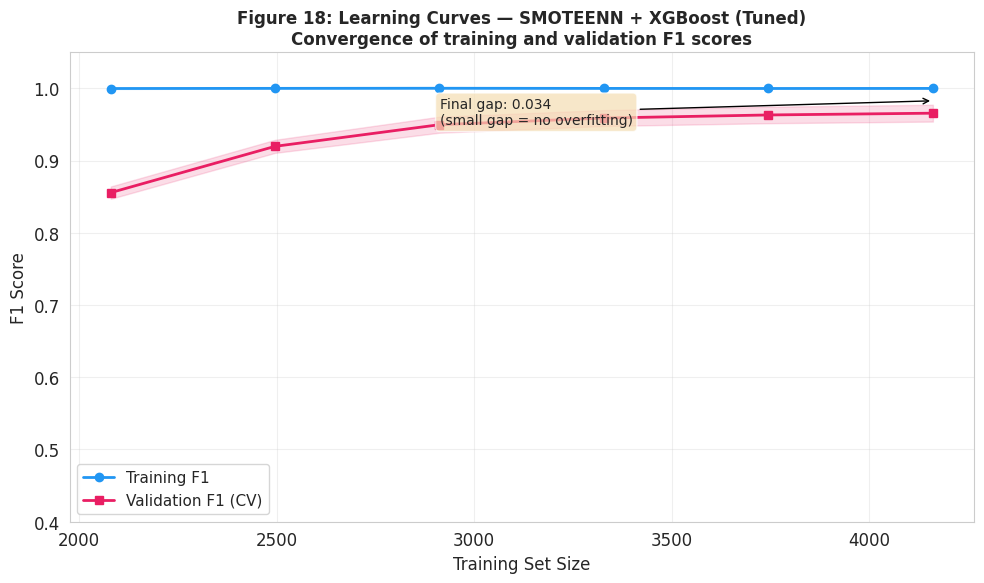


✅ Saved: fig18_learning_curves.png
   Final training F1   : 0.9998
   Final validation F1 : 0.9655
   Gap                 : 0.0343
   ✅ Small gap — model generalizes well. No overfitting.


In [ ]:
# ============================================================
# ADDITION CELL B — Learning curves for final model
# Proves model is not overfitting
# Figure 18 in your paper
# ============================================================

from sklearn.model_selection import learning_curve

print("Generating learning curves — takes 3-4 minutes...")

train_sizes, train_scores, val_scores = learning_curve(
    XGBClassifier(
        **results['tuning']['XGBoost_SMOTEENN']['best_params'],
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    X_train_res, y_train_res,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='f1',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(train_sizes, train_mean, 'o-',
        color='#2196F3', linewidth=2, label='Training F1')
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color='#2196F3')

ax.plot(train_sizes, val_mean, 's-',
        color='#E91E63', linewidth=2, label='Validation F1 (CV)')
ax.fill_between(train_sizes,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.15, color='#E91E63')

ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Figure 18: Learning Curves — SMOTEENN + XGBoost (Tuned)\n'
             'Convergence of training and validation F1 scores',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0.4, 1.05])

# Annotate final gap
final_gap = abs(train_mean[-1] - val_mean[-1])
ax.annotate(
    f'Final gap: {final_gap:.3f}\n(small gap = no overfitting)',
    xy=(train_sizes[-1], (train_mean[-1] + val_mean[-1]) / 2),
    xytext=(train_sizes[-1] * 0.7, 0.95),
    fontsize=10,
    arrowprops=dict(arrowstyle='->', color='black'),
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7)
)

plt.tight_layout()
plt.savefig('fig18_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Save learning curve data
results['learning_curves'] = {
    'train_sizes'  : train_sizes.tolist(),
    'train_mean'   : train_mean.tolist(),
    'val_mean'     : val_mean.tolist(),
    'final_train'  : round(float(train_mean[-1]), 4),
    'final_val'    : round(float(val_mean[-1]), 4),
    'final_gap'    : round(final_gap, 4)
}
print(f"\n✅ Saved: fig18_learning_curves.png")
print(f"   Final training F1   : {train_mean[-1]:.4f}")
print(f"   Final validation F1 : {val_mean[-1]:.4f}")
print(f"   Gap                 : {final_gap:.4f}")
if final_gap < 0.05:
    print("   ✅ Small gap — model generalizes well. No overfitting.")
elif final_gap < 0.10:
    print("   ⚠️  Moderate gap — slight overfitting. Acceptable.")
else:
    print("   ❌ Large gap — overfitting detected. Consider regularization.")